Section 1 contains detailed analysis (EDA) on application_data to identify the important features which help us to identify the defaulters

In [23]:
#Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import itertools

In [24]:
application_data = pd.read_csv('application_data.csv')
previous_application = pd.read_csv('previous_application.csv')
columns_description = pd.read_csv('columns_description.csv')

In [25]:
columns_description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_data,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_data,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_data,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_data,CODE_GENDER,Gender of the client,NaN
4,7,application_data,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [26]:
#Data Dimensions
print(application_data.shape,previous_application.shape,columns_description.shape)

(307511, 122) (1670214, 37) (160, 5)


In [27]:
#Diplaying the first 3 rows of the application_data
application_data.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
#Displaying the first 3 rows of previous_application
previous_application.head(3)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0


In [29]:
#Displaying the first 3 rows of columns_description
columns_description.head(3)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_data,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_data,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_data,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN


,index,Percentage
14,RATE_INTEREST_PRIVILEGED,99.643698
13,RATE_INTEREST_PRIMARY,99.643698
6,AMT_DOWN_PAYMENT,53.636480
12,RATE_DOWN_PAYMENT,53.636480
20,NAME_TYPE_SUITE,49.119754
36,NFLAG_INSURED_ON_APPROVAL,40.298129
35,DAYS_TERMINATION,40.298129
34,DAYS_LAST_DUE,40.298129
33,DAYS_LAST_DUE_1ST_VERSION,40.298129
32,DAYS_FIRST_DUE,40.298129


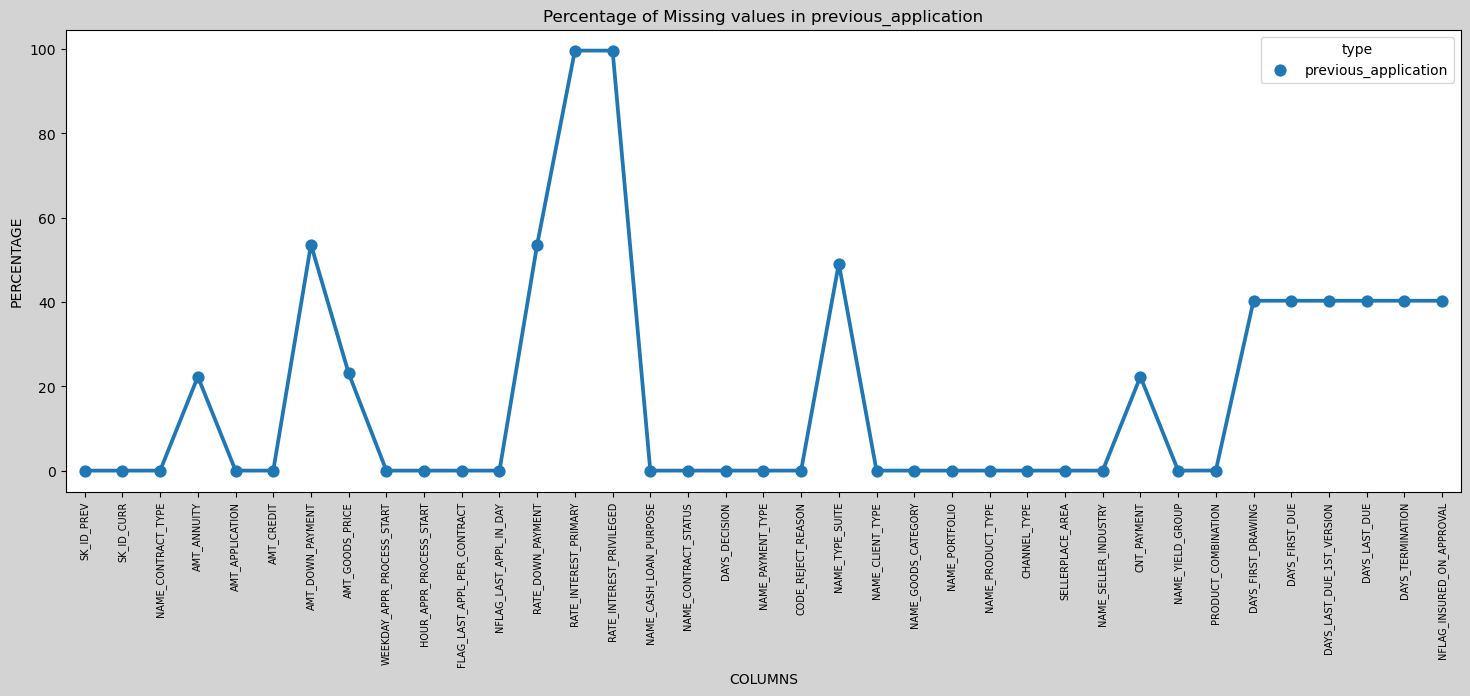

In [30]:
#Percenntage of missing values in previous_application
fig = plt.figure(figsize=(18,6))
miss_previous_application = pd.DataFrame((previous_application.isnull().sum())*100/previous_application.shape[0]).reset_index()
miss_previous_application["type"] = "previous_application"
ax = sns.pointplot("index",0,data = miss_previous_application,hue = "type")
plt.xticks(rotation = 90, fontsize = 7)
plt.title("Percentage of Missing values in previous_application")
plt.ylabel("PERCENTAGE")
plt.xlabel("COLUMNS")
#ax.set_facecolor("k")
fig.set_facecolor("lightgrey")

a = pd.DataFrame((previous_application.isnull().sum())*100/previous_application.shape[0]).reset_index().rename(columns={0:'Percentage'})
a.sort_values('Percentage',ascending=False).head(10)

#Observations
#RATE_INTEREST_PRIVILEGED,RATE_INTEREST_PRIMARY has the maximum NA values followed by AMT_DOWN_PAYMENT and RATE_DOWN_PAYMENT

In [31]:
#Removing columns with missing  values more than 50%
#As per Industrial Standard, max Threshold limit can be between 40% to 50 % depending upon the data acquired in specific sector.
previous_application.drop(['RATE_INTEREST_PRIVILEGED',
                                                 'RATE_INTEREST_PRIMARY',
                                                 'AMT_DOWN_PAYMENT',
                                                 'RATE_DOWN_PAYMENT'],axis=1,inplace=True)

,index,Percentage
16,NAME_TYPE_SUITE,49.119754
27,DAYS_FIRST_DRAWING,40.298129
31,DAYS_TERMINATION,40.298129
30,DAYS_LAST_DUE,40.298129
29,DAYS_LAST_DUE_1ST_VERSION,40.298129
28,DAYS_FIRST_DUE,40.298129
32,NFLAG_INSURED_ON_APPROVAL,40.298129
6,AMT_GOODS_PRICE,23.081773
3,AMT_ANNUITY,22.286665
24,CNT_PAYMENT,22.286366


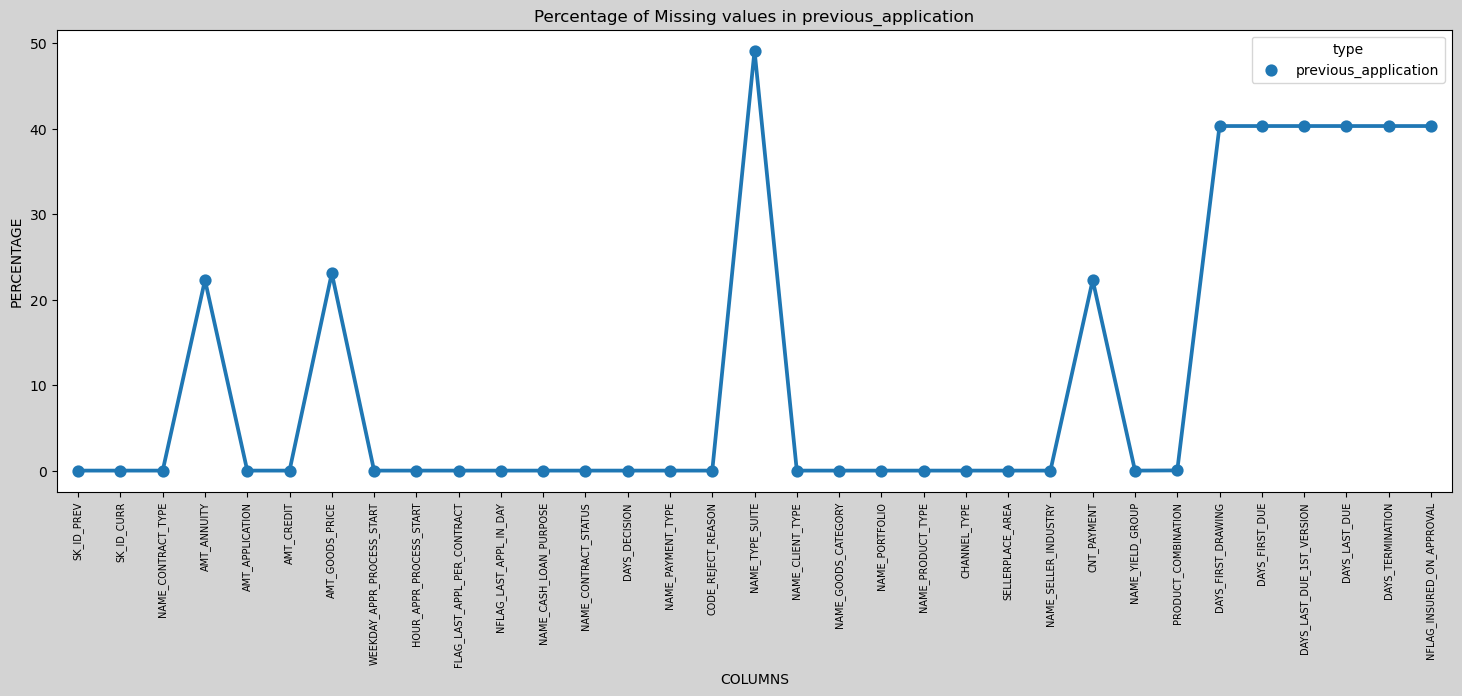

In [32]:
#Percentage of missing values in previous_application after deleting the records with missing values more than 90%
fig = plt.figure(figsize=(18,6))
miss_previous_application = pd.DataFrame((previous_application.isnull().sum())*100/previous_application.shape[0]).reset_index()
miss_previous_application["type"] = "previous_application"
ax = sns.pointplot("index",0,data = miss_previous_application,hue = "type")
plt.xticks(rotation = 90, fontsize = 7)
plt.title("Percentage of Missing values in previous_application")
plt.ylabel("PERCENTAGE")
plt.xlabel("COLUMNS")
#ax.set_facecolor("k")
fig.set_facecolor("lightgrey")

miss_value_percent = pd.DataFrame((previous_application.isnull().sum())*100/previous_application.shape[0]).reset_index().rename(columns={0:'Percentage'})
miss_value_percent.sort_values('Percentage',ascending=False).head(10)

# Handling Missing Values

# PREVIOUS_APPLICATION

AMT_ANNUITY

In [33]:
#AMT_ANNUITY
print("AMT_ANNUITY NULL COUNT:",previous_application['AMT_ANNUITY'].isnull().sum())

AMT_ANNUITY NULL COUNT: 372235


In [34]:
previous_application["AMT_ANNUITY"].describe()

count    1.297979e+06
mean     1.595512e+04
std      1.478214e+04
min      0.000000e+00
25%      6.321780e+03
50%      1.125000e+04
75%      2.065842e+04
max      4.180581e+05
Name: AMT_ANNUITY, dtype: float64

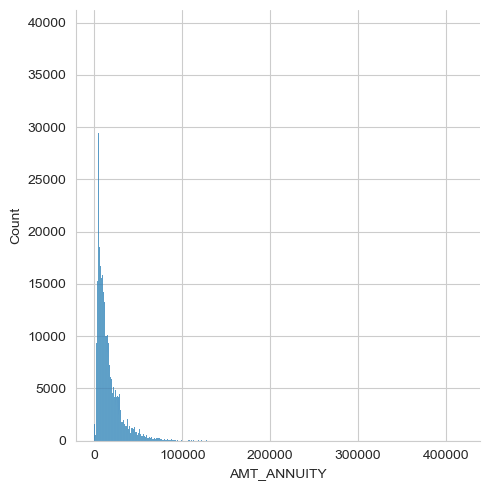

In [35]:
sns.set_style("whitegrid")
sns.displot(previous_application['AMT_ANNUITY'])
plt.show()

#As per the distribution plot it is displayed as right skewed

In [36]:
prev_app_copy = previous_application.copy()

In [37]:
prev_app_copy.dropna(subset=['AMT_ANNUITY'],inplace=True)

In [38]:
previous_application['AMT_ANNUITY'].fillna(prev_app_copy['AMT_ANNUITY'].median(),inplace=True)

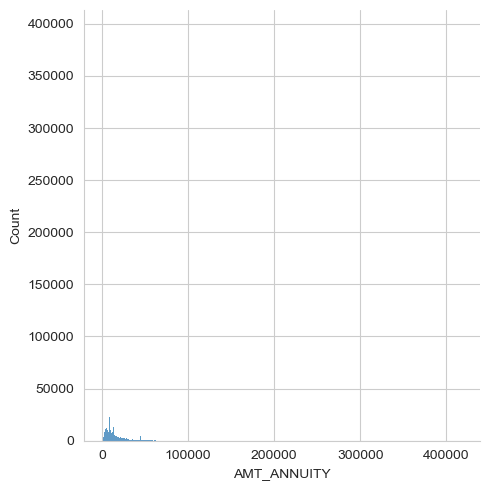

In [39]:
sns.set_style("whitegrid")
sns.displot(previous_application['AMT_ANNUITY'])
plt.show()

#After imputation we have achieved to keep the distribution same

AMT_GOODS_PRICE

AMT_GOODS_PRICE NULL COUNT: 385515


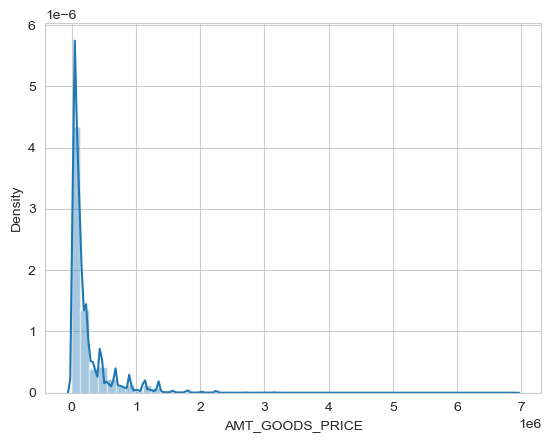

In [40]:
print("AMT_GOODS_PRICE NULL COUNT:",previous_application['AMT_GOODS_PRICE'].isnull().sum())

sns.set_style('whitegrid') 
sns.distplot(previous_application['AMT_GOODS_PRICE']) 
plt.show()

#Here also it reprepresents a right skewed distribution so we can replace the missing values with median

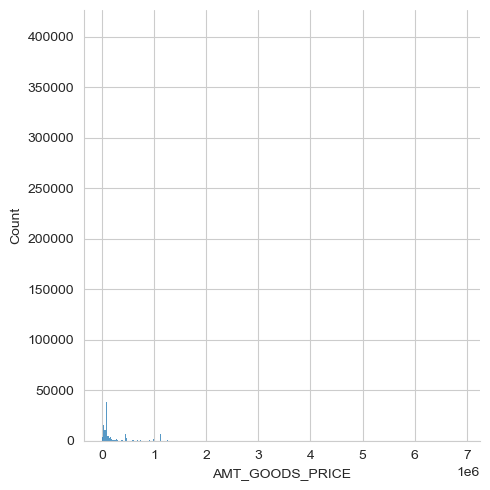

In [41]:
#Replacing the missing values with the mmedian
prev_app_copy_2 = previous_application.copy()
prev_app_copy_2.dropna(subset=['AMT_GOODS_PRICE'],inplace=True)
previous_application['AMT_GOODS_PRICE'].fillna(prev_app_copy_2['AMT_GOODS_PRICE'].median(),inplace=True)
sns.set_style("whitegrid")
sns.displot(previous_application['AMT_GOODS_PRICE'])
plt.show()

NAME_TYPE_SUIT

In [42]:
print("NAME_TYPE_SUIT NULL COUNT:",previous_application['NAME_TYPE_SUITE'].isnull().sum())
previous_application.groupby('NAME_TYPE_SUITE')['NAME_TYPE_SUITE'].count()

NAME_TYPE_SUIT NULL COUNT: 820405


NAME_TYPE_SUITE
Children            31566
Family             213263
Group of people      2240
Other_A              9077
Other_B             17624
Spouse, partner     67069
Unaccompanied      508970
Name: NAME_TYPE_SUITE, dtype: int64

In [43]:
#We can fill NA values with Unaccompanied value that is the mode
previous_application['NAME_TYPE_SUITE'].fillna(previous_application['NAME_TYPE_SUITE'].mode()[0],inplace=True)

CNT_PAYMENT

In [44]:
print("CNT_PAYMENT NULL COUNT:",previous_application['CNT_PAYMENT'].isnull().sum())
previous_application['CNT_PAYMENT'].describe()

CNT_PAYMENT NULL COUNT: 372230


count    1.297984e+06
mean     1.605408e+01
std      1.456729e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.400000e+01
max      8.400000e+01
Name: CNT_PAYMENT, dtype: float64

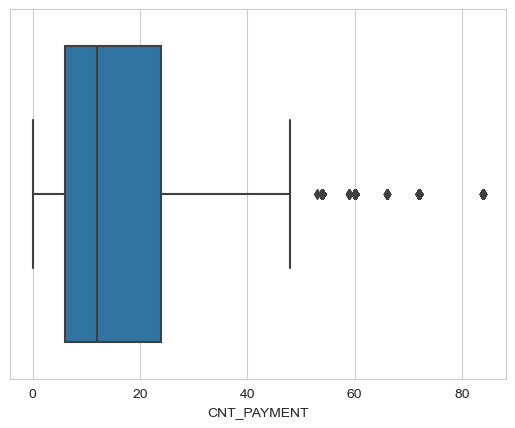

In [45]:
sns.set_style('whitegrid')
sns.boxplot(previous_application['CNT_PAYMENT'])
plt.show()

In [46]:
previous_application['CNT_PAYMENT'].fillna(previous_application['CNT_PAYMENT'].median(),inplace=True)

DAYS_FIRST_DRAWING

In [47]:
print("DAYS_FIRST_DRAWING NULL COUNT:",previous_application['DAYS_FIRST_DRAWING'].isnull().sum())

DAYS_FIRST_DRAWING NULL COUNT: 673065


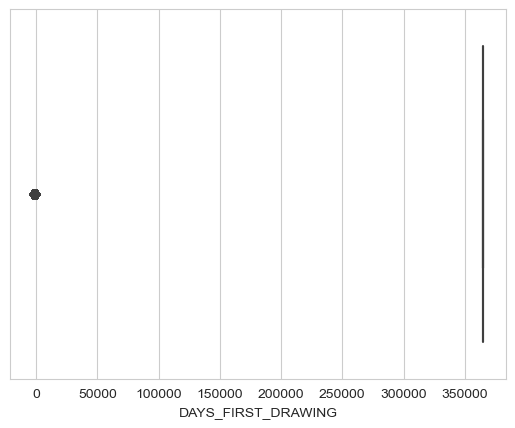

In [48]:
sns.set_style('whitegrid')
sns.boxplot(previous_application['DAYS_FIRST_DRAWING'])
plt.show()

In [49]:
previous_application['DAYS_FIRST_DRAWING'].fillna(previous_application['DAYS_FIRST_DRAWING'].median(),inplace=True)

DAYS_FIRST_DUE

In [50]:
print("DAYS_FIRST_DUE :" ,previous_application['DAYS_FIRST_DUE'].isnull().sum())

DAYS_FIRST_DUE : 673065


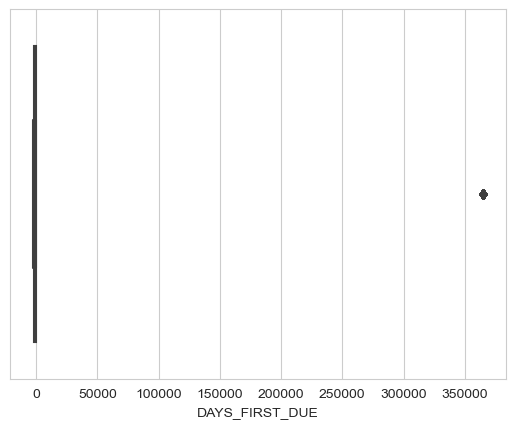

In [51]:
sns.set_style('whitegrid') 
sns.boxplot(previous_application['DAYS_FIRST_DUE']) 
plt.show()

In [52]:
previous_application['DAYS_FIRST_DUE'].fillna(previous_application['DAYS_FIRST_DUE'].median(),inplace=True)

DAYS_LAST_DUE_1ST_VERSION

In [53]:
print("DAYS_LAST_DUE_1ST_VERSION :" ,previous_application['DAYS_LAST_DUE_1ST_VERSION'].isnull().sum())
previous_application['DAYS_LAST_DUE_1ST_VERSION'].describe()

DAYS_LAST_DUE_1ST_VERSION : 673065


count    997149.000000
mean      33767.774054
std      106857.034789
min       -2801.000000
25%       -1242.000000
50%        -361.000000
75%         129.000000
max      365243.000000
Name: DAYS_LAST_DUE_1ST_VERSION, dtype: float64

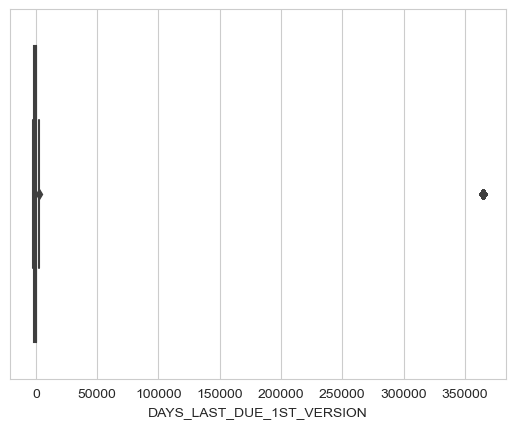

In [54]:
sns.set_style('whitegrid') 
sns.boxplot(previous_application['DAYS_LAST_DUE_1ST_VERSION']) 
plt.show()

In [55]:
previous_application['DAYS_LAST_DUE_1ST_VERSION'].fillna(previous_application['DAYS_LAST_DUE_1ST_VERSION'].median(),inplace=True)

DAYS_LAST_DUE

In [56]:
print("DAYS_LAST_DUE:" ,previous_application['DAYS_LAST_DUE'].isnull().sum())
previous_application['DAYS_LAST_DUE'].describe()

DAYS_LAST_DUE: 673065


count    997149.000000
mean      76582.403064
std      149647.415123
min       -2889.000000
25%       -1314.000000
50%        -537.000000
75%         -74.000000
max      365243.000000
Name: DAYS_LAST_DUE, dtype: float64

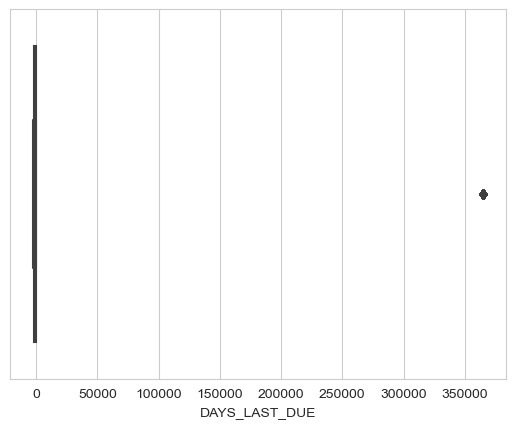

In [57]:
sns.set_style('whitegrid') 
sns.boxplot(previous_application['DAYS_LAST_DUE']) 
plt.show()

In [58]:
previous_application['DAYS_LAST_DUE'].fillna(previous_application['DAYS_LAST_DUE'].median(),inplace=True)

DAYS_TERMINATION

In [59]:
print("DAYS_TERMINATION :" ,previous_application['DAYS_TERMINATION'].isnull().sum())
previous_application['DAYS_TERMINATION'].describe()

DAYS_TERMINATION : 673065


count    997149.000000
mean      81992.343838
std      153303.516729
min       -2874.000000
25%       -1270.000000
50%        -499.000000
75%         -44.000000
max      365243.000000
Name: DAYS_TERMINATION, dtype: float64

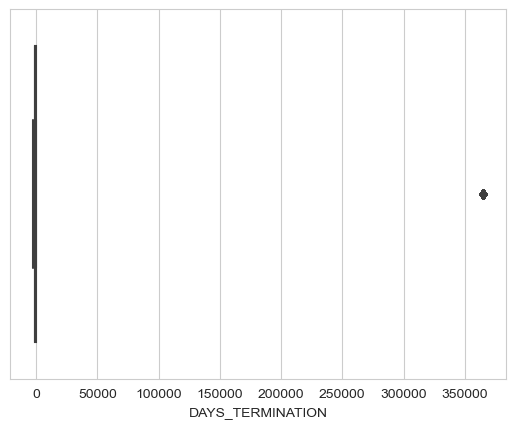

In [60]:
sns.set_style('whitegrid') 
sns.boxplot(previous_application['DAYS_TERMINATION']) 
plt.show()

In [61]:
previous_application['DAYS_TERMINATION'].fillna(previous_application['DAYS_TERMINATION'].median(),inplace=True)

NFLAG_INSURED_ON_APPROVAL

In [62]:
print("NFLAG_INSURED_ON_APPROVAL:" ,previous_application['NFLAG_INSURED_ON_APPROVAL'].isnull().sum())

NFLAG_INSURED_ON_APPROVAL: 673065


In [63]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].value_counts()

0.0    665527
1.0    331622
Name: NFLAG_INSURED_ON_APPROVAL, dtype: int64

In [64]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].fillna(previous_application['NFLAG_INSURED_ON_APPROVAL'].mode()[0],inplace=True)

AMT_CREDIT

In [65]:
print("AMT_CREDIT :" ,previous_application['AMT_CREDIT'].isnull().sum())
previous_application['AMT_CREDIT'].describe()

AMT_CREDIT : 1


count    1.670213e+06
mean     1.961140e+05
std      3.185746e+05
min      0.000000e+00
25%      2.416050e+04
50%      8.054100e+04
75%      2.164185e+05
max      6.905160e+06
Name: AMT_CREDIT, dtype: float64

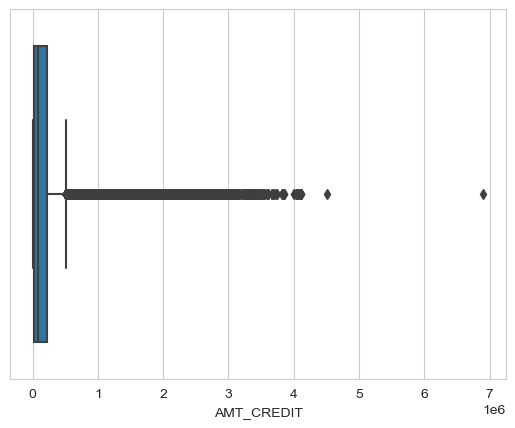

In [66]:
sns.set_style('whitegrid') 
sns.boxplot(previous_application['AMT_CREDIT']) 
plt.show()

In [67]:
previous_application['AMT_CREDIT'].fillna(previous_application['AMT_CREDIT'].median(),inplace=True)

PRODUCT_COMBINATION

In [68]:
print("PRODUCT_COMBINATION :" ,previous_application['PRODUCT_COMBINATION'].isnull().sum())

PRODUCT_COMBINATION : 346


In [69]:
previous_application['PRODUCT_COMBINATION'].value_counts()

Cash                              285990
POS household with interest       263622
POS mobile with interest          220670
Cash X-Sell: middle               143883
Cash X-Sell: low                  130248
Card Street                       112582
POS industry with interest         98833
POS household without interest     82908
Card X-Sell                        80582
Cash Street: high                  59639
Cash X-Sell: high                  59301
Cash Street: middle                34658
Cash Street: low                   33834
POS mobile without interest        24082
POS other with interest            23879
POS industry without interest      12602
POS others without interest         2555
Name: PRODUCT_COMBINATION, dtype: int64

In [70]:
previous_application['PRODUCT_COMBINATION'].fillna(previous_application['PRODUCT_COMBINATION'].mode()[0],inplace=True)

In [71]:
pd.DataFrame((previous_application.isnull().sum())).reset_index().sort_values(0,ascending=False)

,index,0
0,SK_ID_PREV,0
17,NAME_CLIENT_TYPE,0
31,DAYS_TERMINATION,0
30,DAYS_LAST_DUE,0
29,DAYS_LAST_DUE_1ST_VERSION,0
28,DAYS_FIRST_DUE,0
27,DAYS_FIRST_DRAWING,0
26,PRODUCT_COMBINATION,0
25,NAME_YIELD_GROUP,0
24,CNT_PAYMENT,0


In [72]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

Seperating numerical and categorical column from previous_application

In [73]:
obj_types = [i for i in previous_application.select_dtypes(include = np.object).columns if i not in ["TYPE"]]
num_dtypes = [i for i in previous_application.select_dtypes(include=np.number).columns if i not in ['SK_ID_CURR'] + ['TARGET']]

In [74]:
#Displaying the Categorical and Numerical Values
print(color.BOLD + color.PURPLE + 'Categorical Columns' + color.END, "\n")
for i in range(len(obj_types)):
    print(obj_types[i])

Categorical Columns 

NAME_CONTRACT_TYPE
WEEKDAY_APPR_PROCESS_START
FLAG_LAST_APPL_PER_CONTRACT
NAME_CASH_LOAN_PURPOSE
NAME_CONTRACT_STATUS
NAME_PAYMENT_TYPE
CODE_REJECT_REASON
NAME_TYPE_SUITE
NAME_CLIENT_TYPE
NAME_GOODS_CATEGORY
NAME_PORTFOLIO
NAME_PRODUCT_TYPE
CHANNEL_TYPE
NAME_SELLER_INDUSTRY
NAME_YIELD_GROUP
PRODUCT_COMBINATION


In [75]:
print(color.BOLD + color.PURPLE + 'Numerical Columns'+ color.END,"\n")
for i in range(len(num_dtypes)):
    print(num_dtypes[i])

Numerical Columns 

SK_ID_PREV
AMT_ANNUITY
AMT_APPLICATION
AMT_CREDIT
AMT_GOODS_PRICE
HOUR_APPR_PROCESS_START
NFLAG_LAST_APPL_IN_DAY
DAYS_DECISION
SELLERPLACE_AREA
CNT_PAYMENT
DAYS_FIRST_DRAWING
DAYS_FIRST_DUE
DAYS_LAST_DUE_1ST_VERSION
DAYS_LAST_DUE
DAYS_TERMINATION
NFLAG_INSURED_ON_APPROVAL


# Application Data

In [76]:
application_data.shape

(307511, 122)

Percentage of Missing Values in application_data

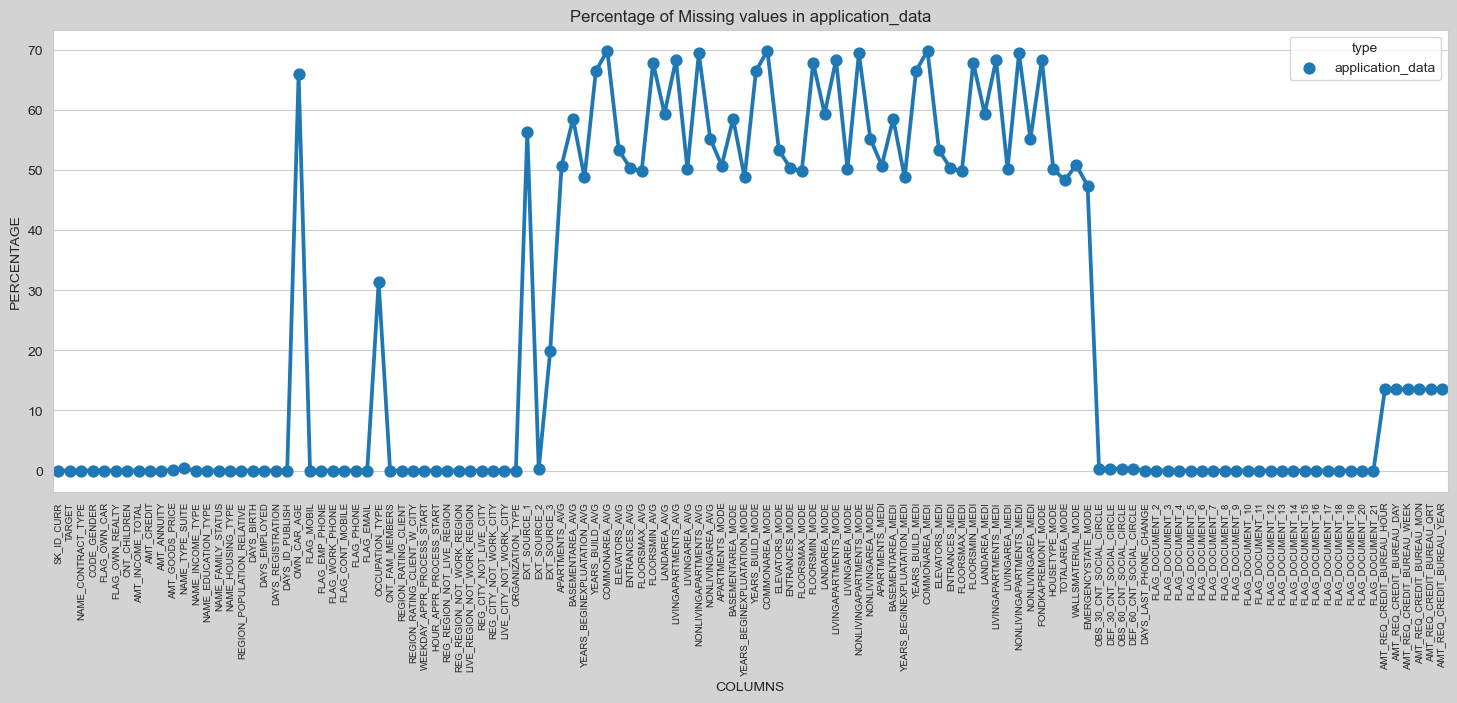

In [77]:
fig = plt.figure(figsize=(18,6))
miss_application_data = pd.DataFrame((application_data.isnull().sum())*100/application_data.shape[0]).reset_index()
miss_application_data['type'] = "application_data"
ax = sns.pointplot("index",0,data = miss_application_data,hue = "type")
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values in application_data")
plt.ylabel("PERCENTAGE")
plt.xlabel("COLUMNS")
fig.set_facecolor("lightgrey")

Removing columns with missing values more than 40%



As per Industrial Standard, max Threshold limit can be between 40% to 50 % depending upon the data acquired in specific sector.

In [78]:
#Excluding column wwhich includes null values over 50 percent
init_columns = pd.DataFrame((application_data.isnull().sum())*100/application_data.shape[0]).reset_index()
init_columns = init_columns[init_columns[0]<50.0]
list_column = init_columns['index'].tolist()
upd_applicationn_data = application_data[list_column]
upd_applicationn_data.shape

(307511, 81)

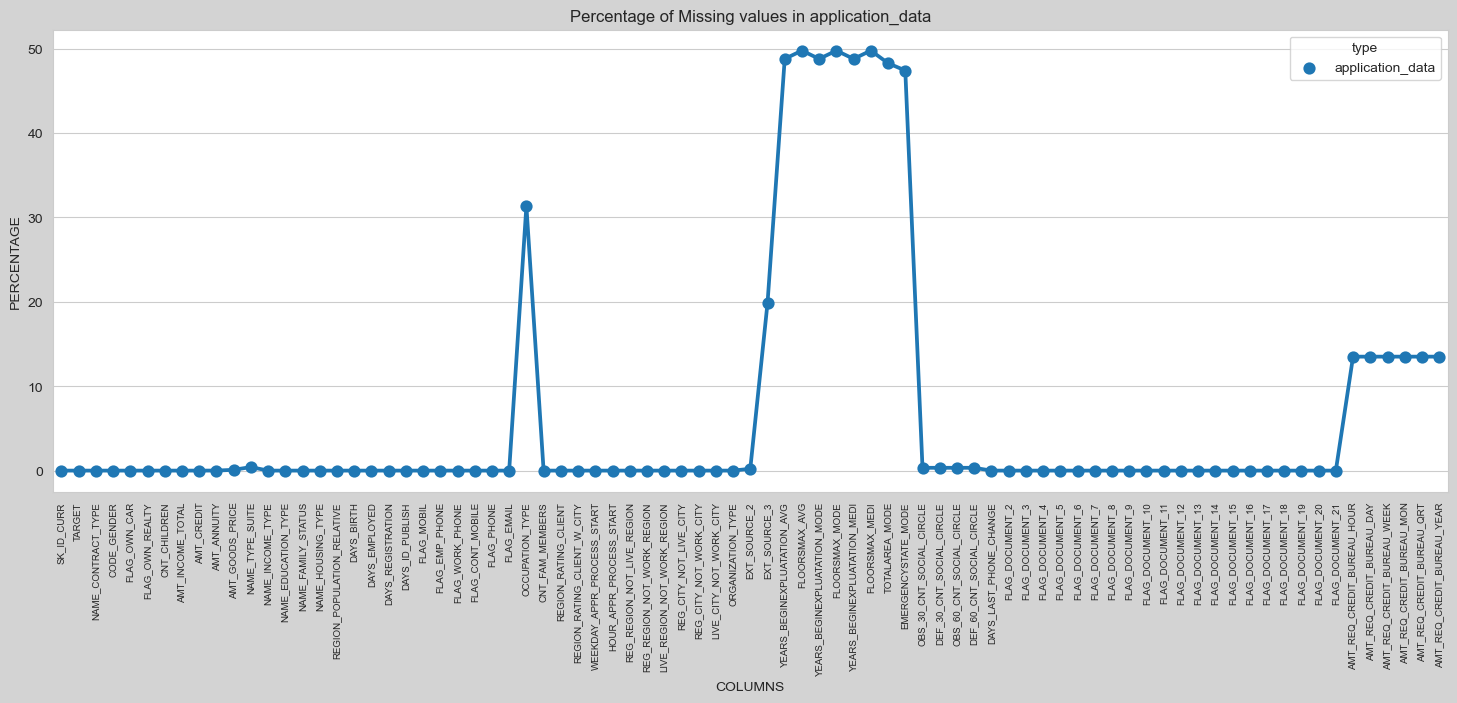

In [79]:
#Plotting the missing values after excluding the columns which is having null vaues over 50 percent
fig = plt.figure(figsize=(18,6))
miss_application_data_upd = pd.DataFrame((upd_applicationn_data.isnull().sum())*100/upd_applicationn_data.shape[0]).reset_index()
miss_application_data_upd["type"] = "application_data"
ax = sns.pointplot("index",0,data = miss_application_data_upd,hue = "type")
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values in application_data")
plt.ylabel("PERCENTAGE")
plt.xlabel("COLUMNS")
#ax.set_facecolor("k")
fig.set_facecolor("lightgrey")

In [80]:
upd_applicationn_data.shape

(307511, 81)

AMT_REQ_CREDIT_BUREAU_DAY

In [81]:
print("AMT_REQ_CREDIT_BUREAU_DAY NAN COUNT :" ,upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_DAY'].isnull().sum())
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_DAY'].describe()

AMT_REQ_CREDIT_BUREAU_DAY NAN COUNT : 41519


count    265992.000000
mean          0.007000
std           0.110757
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: float64

In [82]:
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_DAY'].fillna(upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_DAY'].median(),inplace=True)

AMT_REQ_CREDIT_BUREAU_MON

In [83]:
print("AMT_REQ_CREDIT_BUREAU_MON NAN COUNT :" ,upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_MON'].isnull().sum())
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_MON'].describe()

AMT_REQ_CREDIT_BUREAU_MON NAN COUNT : 41519


count    265992.000000
mean          0.267395
std           0.916002
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          27.000000
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: float64

In [84]:
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_MON'].fillna(upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_MON'].median(),inplace=True)

AMT_REQ_CREDIT_BUREAU_QRT

In [85]:
print("AMT_REQ_CREDIT_BUREAU_QRT NAN COUNT :" ,upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_QRT'].isnull().sum())
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_QRT'].describe()

AMT_REQ_CREDIT_BUREAU_QRT NAN COUNT : 41519


count    265992.000000
mean          0.265474
std           0.794056
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         261.000000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64

In [86]:
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_QRT'].fillna(upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_QRT'].median(),inplace=True)

AMT_REQ_CREDIT_BUREAU_WEEK

In [87]:
print("AMT_REQ_CREDIT_BUREAU_WEEK NAN COUNT :" ,upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_WEEK'].isnull().sum())
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_WEEK'].describe()

AMT_REQ_CREDIT_BUREAU_WEEK NAN COUNT : 41519


count    265992.000000
mean          0.034362
std           0.204685
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: float64

In [88]:
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_WEEK'].fillna(upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_WEEK'].median(),inplace=True)

AMT_REQ_CREDIT_BUREAU_YEAR

In [89]:
print("AMT_REQ_CREDIT_BUREAU_YEAR NAN COUNT :" ,upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull().sum())
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_YEAR'].describe()

AMT_REQ_CREDIT_BUREAU_YEAR NAN COUNT : 41519


count    265992.000000
mean          1.899974
std           1.869295
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          25.000000
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: float64

In [90]:
upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_YEAR'].fillna(upd_applicationn_data['AMT_REQ_CREDIT_BUREAU_YEAR'].median(),inplace=True)

DEF_30_CNT_SOCIAL_CIRCLE

In [91]:
print("DEF_30_CNT_SOCIAL_CIRCLE NAN COUNT :" ,upd_applicationn_data['DEF_30_CNT_SOCIAL_CIRCLE'].isnull().sum())
upd_applicationn_data['DEF_30_CNT_SOCIAL_CIRCLE'].describe()

DEF_30_CNT_SOCIAL_CIRCLE NAN COUNT : 1021


count    306490.000000
mean          0.143421
std           0.446698
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          34.000000
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64

In [92]:
upd_applicationn_data['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(upd_applicationn_data['DEF_30_CNT_SOCIAL_CIRCLE'].median(),inplace=True)

DEF__60_CNT_SOCIAL_CIRCLE

In [93]:
print("DEF_60_CNT_SOCIAL_CIRCLE :" ,upd_applicationn_data['DEF_60_CNT_SOCIAL_CIRCLE'].isnull().sum())
upd_applicationn_data['DEF_60_CNT_SOCIAL_CIRCLE'].describe()

DEF_60_CNT_SOCIAL_CIRCLE : 1021


count    306490.000000
mean          0.100049
std           0.362291
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64

In [94]:
upd_applicationn_data['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(upd_applicationn_data['DEF_60_CNT_SOCIAL_CIRCLE'].median(),inplace=True)

OBS_60_CNT_SOCIAL_CIRCLE

In [95]:
print("OBS_60_CNT_SOCIAL_CIRCLE :" ,upd_applicationn_data['OBS_60_CNT_SOCIAL_CIRCLE'].isnull().sum())
upd_applicationn_data['OBS_60_CNT_SOCIAL_CIRCLE'].describe()

OBS_60_CNT_SOCIAL_CIRCLE : 1021


count    306490.000000
mean          1.405292
std           2.379803
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         344.000000
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: float64

In [96]:
upd_applicationn_data['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(upd_applicationn_data['OBS_60_CNT_SOCIAL_CIRCLE'].median(),inplace=True)

AMT_ANNUITY

In [97]:
print("AMT_ANNUITY  :" ,upd_applicationn_data['AMT_ANNUITY'].isnull().sum())
upd_applicationn_data['AMT_ANNUITY'].describe()

AMT_ANNUITY  : 12


count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

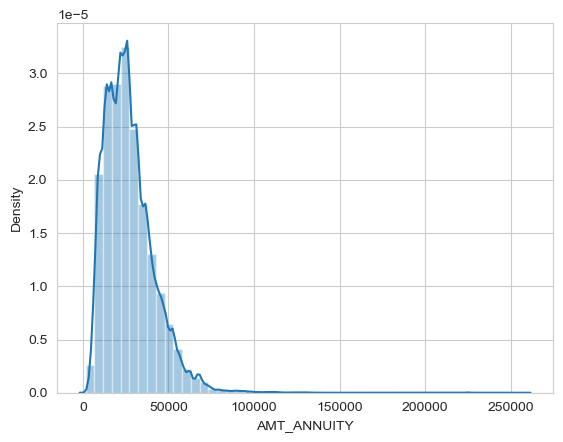

In [98]:
sns.set_style('whitegrid') 
sns.distplot(upd_applicationn_data['AMT_ANNUITY']) 
plt.show()

In [99]:
upd_applicationn_data['AMT_ANNUITY'].fillna(upd_applicationn_data['AMT_ANNUITY'].mean(),inplace=True)

AMT_GOODS_PRICE

In [100]:
print("AMT_GOODS_PRICE   :" ,upd_applicationn_data['AMT_GOODS_PRICE'].isnull().sum())
upd_applicationn_data['AMT_GOODS_PRICE'].describe()

AMT_GOODS_PRICE   : 278


count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

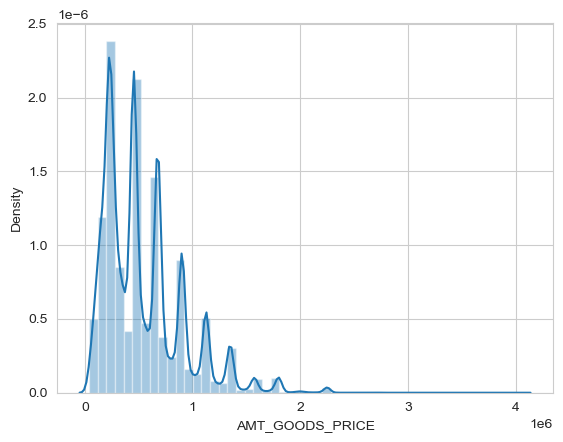

In [101]:
sns.set_style('whitegrid') 
sns.distplot(upd_applicationn_data['AMT_GOODS_PRICE']) 
plt.show()

In [102]:
upd_applicationn_data['AMT_GOODS_PRICE'].fillna(upd_applicationn_data['AMT_GOODS_PRICE'].mean(),inplace=True)

NAME_TYPE_SUITE

In [103]:
print("NAME_TYPE_SUITE :" ,upd_applicationn_data['NAME_TYPE_SUITE'].isnull().sum())
upd_applicationn_data['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE : 1292


Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: NAME_TYPE_SUITE, dtype: int64

In [104]:
upd_applicationn_data['NAME_TYPE_SUITE'].fillna(upd_applicationn_data['AMT_GOODS_PRICE'].mode()[0],inplace=True)

CNT_FAM_MEMBERS

In [105]:
print("CNT_FAM_MEMBERS :" ,upd_applicationn_data['CNT_FAM_MEMBERS'].isnull().sum())
upd_applicationn_data['CNT_FAM_MEMBERS'].describe()

CNT_FAM_MEMBERS : 2


count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

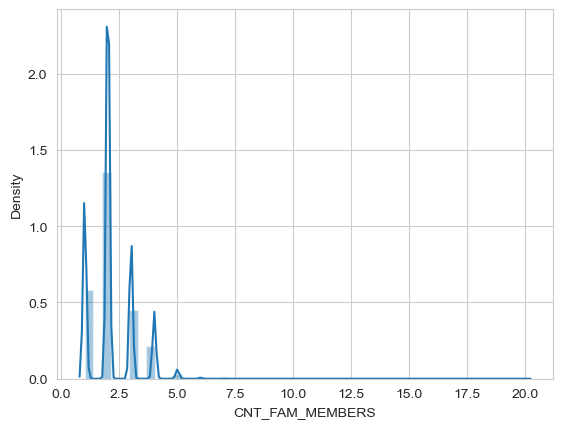

In [106]:
sns.set_style('whitegrid') 
sns.distplot(upd_applicationn_data['CNT_FAM_MEMBERS']) 
plt.show()

In [107]:
upd_applicationn_data['CNT_FAM_MEMBERS'].fillna(upd_applicationn_data['CNT_FAM_MEMBERS'].median(),inplace=True)

DAYS_LAST_PHONE_CHANGE

In [108]:
print("DAYS_LAST_PHONE_CHANGE :" ,upd_applicationn_data['DAYS_LAST_PHONE_CHANGE'].isnull().sum())
upd_applicationn_data['DAYS_LAST_PHONE_CHANGE'].describe()

DAYS_LAST_PHONE_CHANGE : 1


count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64

In [109]:
upd_applicationn_data['DAYS_LAST_PHONE_CHANGE'].fillna(upd_applicationn_data['DAYS_LAST_PHONE_CHANGE'].mode()[0],inplace=True)

In [110]:
#Implementing absolute function to remove nagtive values using loop
negative_to_pos = ['DAYS_BIRTH','DAYS_ID_PUBLISH','DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE']
for i in range(len(negative_to_pos)):
    column_name = negative_to_pos[i]
    upd_applicationn_data[column_name] = upd_applicationn_data[column_name].abs()

In [111]:
#Seperate categoricall aand numerical data
obj_dtypes = [i for i in upd_applicationn_data.select_dtypes(include = np.object).columns if i not in ["TYPE"]]
num_dtypes = [i for i in upd_applicationn_data.select_dtypes(include = np.number).columns if i not in ['SK_ID_CURR'] + ['TARGET']]

In [112]:
print(color.BOLD + color.PURPLE + 'Categorical Columns' + color.END, "\n")
for x in range(len(obj_dtypes)): 
    print(obj_dtypes[x])

Categorical Columns 

NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
OCCUPATION_TYPE
WEEKDAY_APPR_PROCESS_START
ORGANIZATION_TYPE
EMERGENCYSTATE_MODE


In [113]:
print(color.BOLD + color.PURPLE +"Numerical Columns" + color.END, "\n")
for x in range(len(num_dtypes)): 
    print(num_dtypes[x])

Numerical Columns 

CNT_CHILDREN
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AMT_GOODS_PRICE
REGION_POPULATION_RELATIVE
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_REGISTRATION
DAYS_ID_PUBLISH
FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
FLAG_EMAIL
CNT_FAM_MEMBERS
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
HOUR_APPR_PROCESS_START
REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
EXT_SOURCE_2
EXT_SOURCE_3
YEARS_BEGINEXPLUATATION_AVG
FLOORSMAX_AVG
YEARS_BEGINEXPLUATATION_MODE
FLOORSMAX_MODE
YEARS_BEGINEXPLUATATION_MEDI
FLOORSMAX_MEDI
TOTALAREA_MODE
OBS_30_CNT_SOCIAL_CIRCLE
DEF_30_CNT_SOCIAL_CIRCLE
OBS_60_CNT_SOCIAL_CIRCLE
DEF_60_CNT_SOCIAL_CIRCLE
DAYS_LAST_PHONE_CHANGE
FLAG_DOCUMENT_2
FLAG_DOCUMENT_3
FLAG_DOCUMENT_4
FLAG_DOCUMENT_5
FLAG_DOCUMENT_6
FLAG_DOCUMENT_7
FLAG_DOCUMENT_8
FLAG_DOCUMENT_9
FLAG_DOCUMENT_10
FLAG_DOCUMENT_11
FLAG_DOCUMENT_12
FLAG_DOCUMENT_13
FLAG_DOCUMENT

Imbalance Percenntage

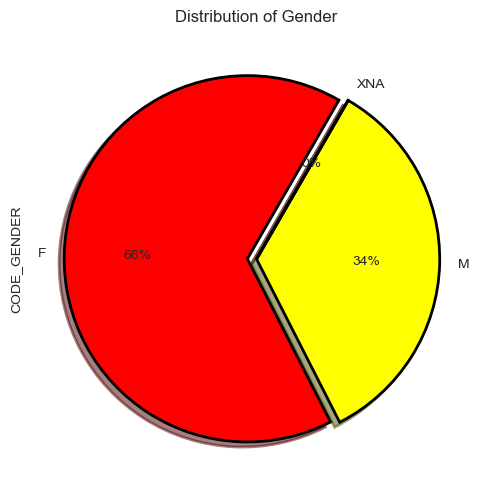

In [125]:
fig = plt.figure(figsize=(13,6))
plt.subplot(121)
upd_applicationn_data['CODE_GENDER'].value_counts().plot.pie(autopct = "%1.0f%%",
                            colors = ["red","yellow"],startangle = 60,
                            wedgeprops = {"linewidth":2,"edgecolor":"k"},explode = [.05,0,0],
                            shadow = True)
plt.title("Distribution of Gender")
plt.show()

#Its a non balanced data

Distribution of the target variable

TARGET : Target variable 
     1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in sample,
     0 - all other cases

In [128]:
upd_applicationn_data["TARGET"].value_counts()

0    282686
1     24825
Name: TARGET, dtype: int64

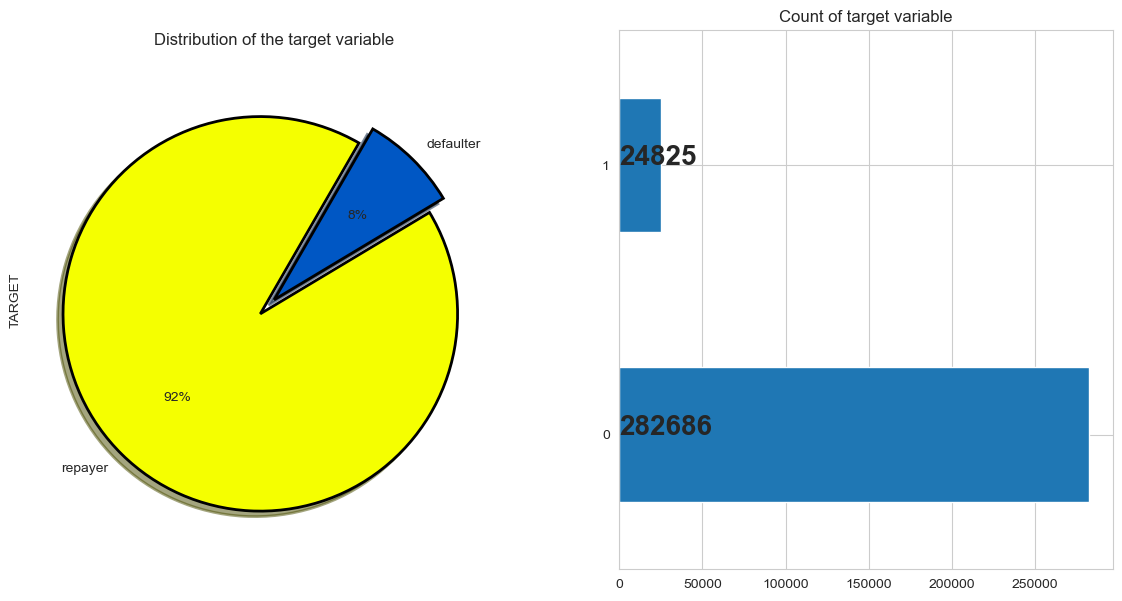

In [133]:
plt.figure(figsize=(14,7))
plt.subplot(121)
upd_applicationn_data["TARGET"].value_counts().plot.pie(autopct = "%1.0f%%",
                        colors = sns.color_palette("prism",7),startangle=60,
                        labels = ["repayer","defaulter"],
                        wedgeprops = {"linewidth":2,"edgecolor":"k"},
                        explode = [.1,0],shadow=True)
plt.title("Distribution of the target variable")
plt.subplot(122)
ax = upd_applicationn_data["TARGET"].value_counts().plot(kind="barh")
for i,j in enumerate(upd_applicationn_data["TARGET"].value_counts().values):
    ax.text(0.7,i,j,weight="bold",fontsize=20)#(x,y,text)
plt.title("Count of target variable")
plt.show()

#Perecntage of population among the total who are facing problem in repaying the loans is 8&

Concatenating upd_applicationn_data and previous_application

In [135]:
application_data_x =  application_data[[x for x in application_data.columns if x not in ["TARGET"]]]
previous_application_x = previous_application[[x for x in previous_application.columns if x not in ["TARGET"]]]
application_data_x["type"] = "application_data"
previous_application_x["type"] = "previous_application"
data = pd.concat([application_data_x,previous_application_x],axis=0)

In [94]:
data.shape

(1977725, 147)

Distribution in Contract types in application_data

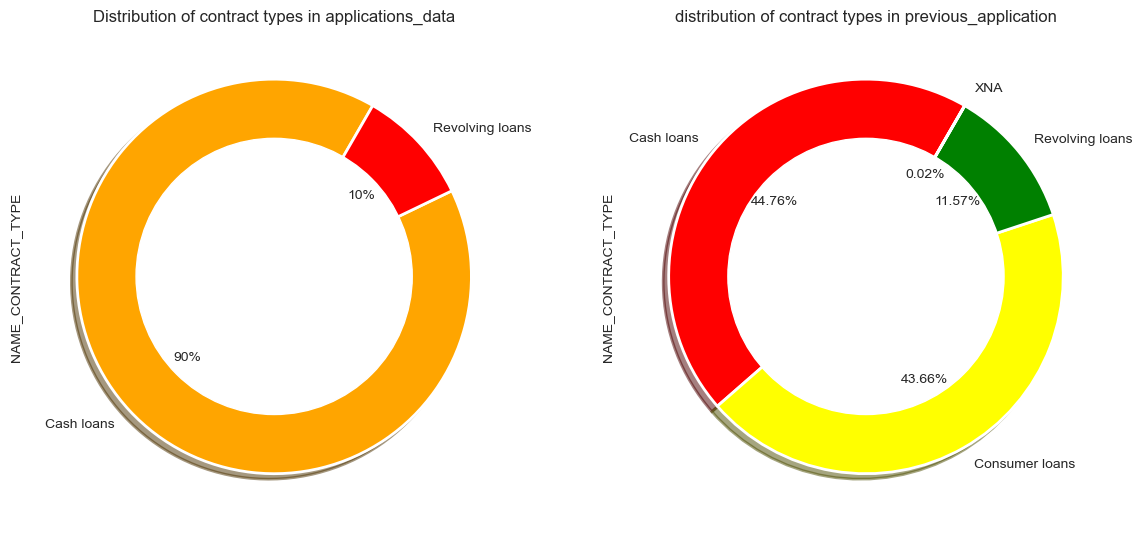

In [139]:
plt.figure(figsize=(14,7))
plt.subplot(121)
data[data["type"]=="application_data"]["NAME_CONTRACT_TYPE"].value_counts().plot.pie(autopct = "%1.0f%%",colors=["orange","red"],startangle = 60,
                                                                                    wedgeprops = {"linewidth": 2,"edgecolor":"white"},
                                                                                    shadow = True)
circ = plt.Circle((0,0),0.7,color = "white")
plt.gca().add_artist(circ)
plt.title("Distribution of contract types in applications_data")
plt.subplot(122)
data[data["type"]=="previous_application"]["NAME_CONTRACT_TYPE"].value_counts().plot.pie(autopct="%1.2f%%",colors = ["red","yellow","green","BLACK"],startangle=60,
                                                                                       wedgeprops = {"linewidth":2,"edgecolor":"white"},shadow=True)
circ = plt.Circle((0,0),0.7,color = "white")
plt.gca().add_artist(circ)
plt.title("distribution of contract types in previous_application")
plt.show()

plt.show()

#Current Application : 90%(Majority) loan are of cash loans in the current application
#Previous application : 43.66%(Majority) loan are of consumer loans in the previous application

Distribution of Contract type by gender

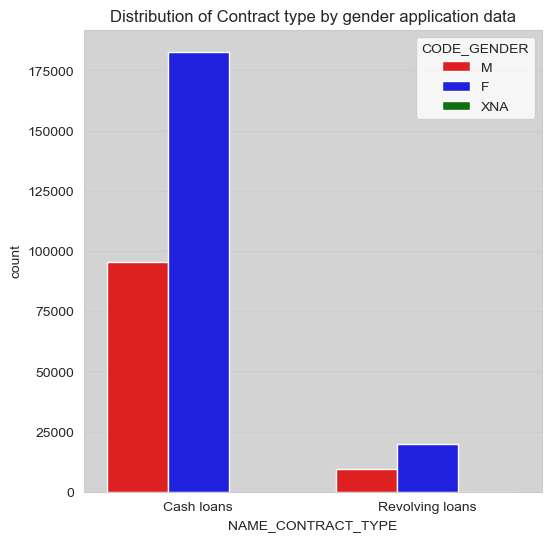

In [96]:
fig = plt.figure(figsize=(13,6))
plt.subplot(121)
ax = sns.countplot("NAME_CONTRACT_TYPE",hue="CODE_GENDER",
                   data = data[data["type"]=="application_data"],
                  palette = ["r","b","g"])
ax.set_facecolor("lightgrey")
ax.set_title("Distribution of Contract type by gender application data")
plt.show()

#From the contract type both cash loans and revolving loan 
#are applied by females more than males

#Cash Loan is always preferres over revolving loans

Distribution of client owning a car and by gender

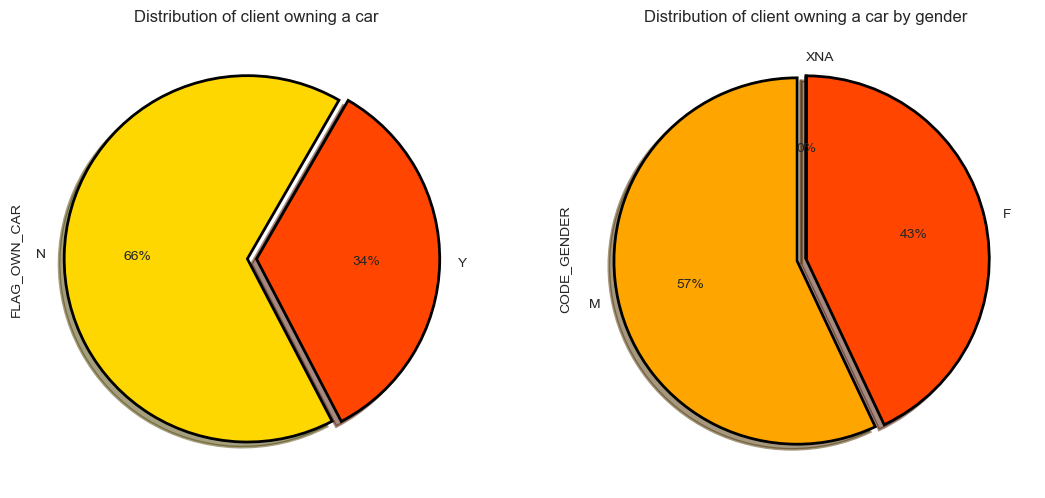

In [97]:
fig = plt.figure(figsize=(13,6))

plt.subplot(121)
data['FLAG_OWN_CAR'].value_counts().plot.pie(autopct = "%1.0f%%",
                        colors = ["gold","orangered"],startangle = 60,
                        wedgeprops ={"linewidth":2,"edgecolor":"k"},
                        explode = [0.05,0],shadow = True)
plt.title("Distribution of client owning a car")

plt.subplot(122)
data[data['FLAG_OWN_CAR']=="Y"]["CODE_GENDER"].value_counts().plot.pie(autopct="%1.0f%%",colors = ["orange","orangered"],startangle=90,
         wedgeprops = {"linewidth":2,"edgecolor":"k"},explode=(0.05,0,0),
        shadow=True)
plt.title("Distribution of client owning a car by gender")
plt.show()

#Subplot 1 : Distriution of client owning a car is 34%
#Subplot 2 : Among the genders who own a car 57% of then are males.

Distribution of client owning a house or flat and by gender

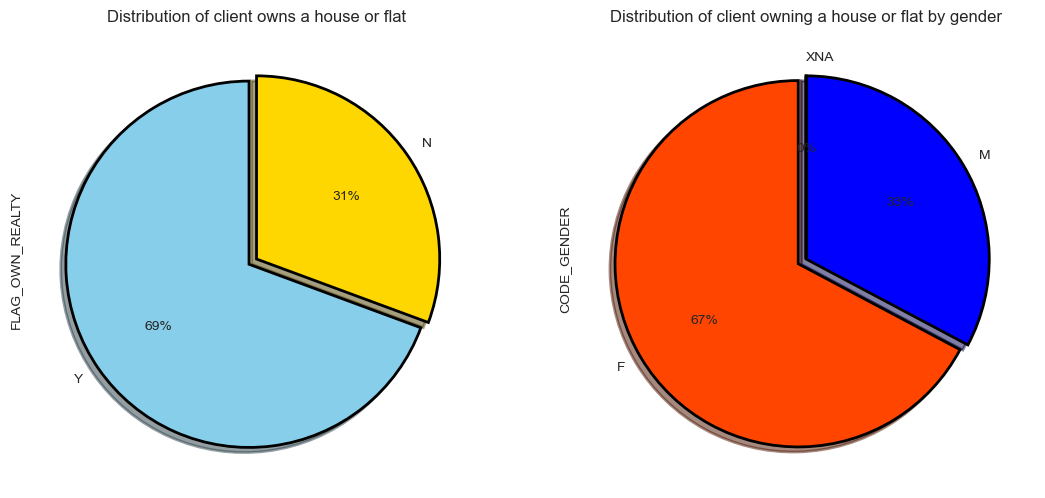

In [98]:
plt.figure(figsize=(13,6))
plt.subplot(121)#1 = Row,#2 - Column,#3 - Index
data['FLAG_OWN_REALTY'].value_counts().plot.pie(autopct = "%1.0f%%",
                        colors = ["skyblue","gold"],startangle = 90,
                        wedgeprops = {"linewidth":2,"edgecolor":"k"},
                        explode = [0.05,0],shadow = True)
plt.title("Distribution of client owns a house or flat")

plt.subplot(122)
data[data['FLAG_OWN_REALTY']=="Y"]["CODE_GENDER"].value_counts().plot.pie(autopct = "%1.0f%%",
                         colors = ["orangered","b"],startangle = 90,wedgeprops = {"linewidth":2,"edgecolor":"k"},
                        explode = [0.05,0,0],shadow = True)
plt.title("Distribution of client owning a house or flat by gender")
plt.show()

#Subplot 1 : 69% of the people owns a house
#Subplot 2 : Out of the total population who owns a house 67% are females

Distribution of Number of children and family members of client by repayment status.

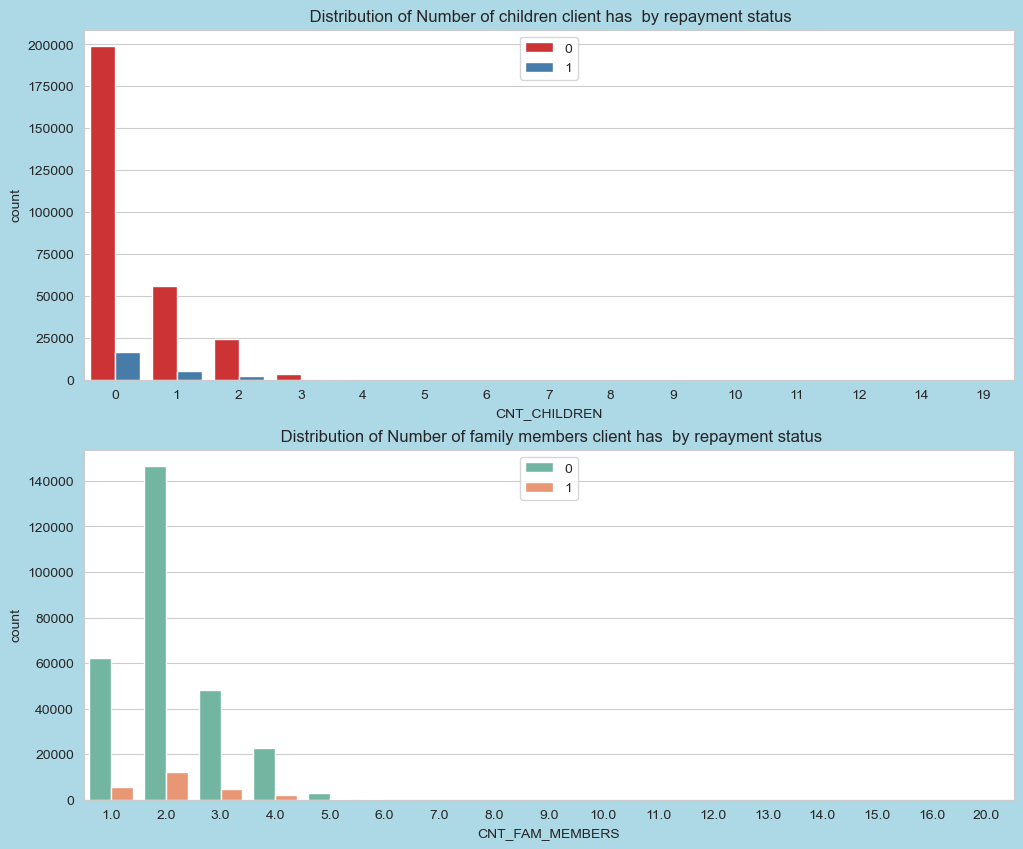

In [99]:
fig = plt.figure(figsize=(12,10))
plt.subplot(211)
sns.countplot(upd_applicationn_data["CNT_CHILDREN"],palette="Set1",hue=upd_applicationn_data["TARGET"])
plt.legend(loc="upper center")
plt.title(" Distribution of Number of children client has  by repayment status")
plt.subplot(212)
sns.countplot(upd_applicationn_data["CNT_FAM_MEMBERS"],palette="Set2",hue=upd_applicationn_data["TARGET"])
plt.legend(loc="upper center")
plt.title(" Distribution of Number of family members client has  by repayment status")
fig.set_facecolor("lightblue")
#Subplot 1 : People with zero children has the most default
#Subplot 2 : Family of two members has defaulted most

Distribution of contract type ,gender ,own car ,own house with respect to Repayment status(Target variable)

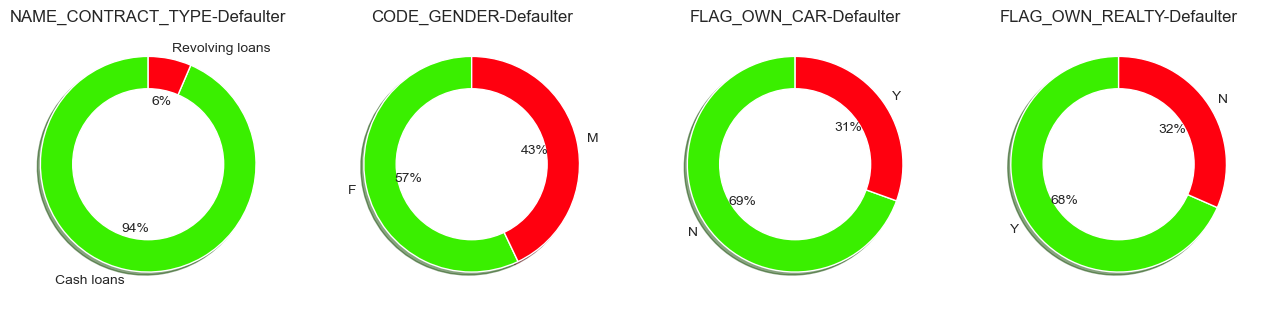

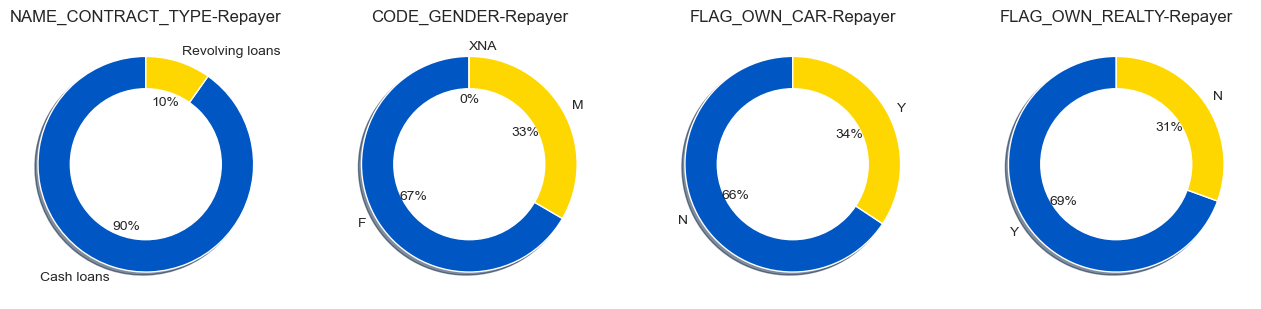

In [100]:
default = upd_applicationn_data[upd_applicationn_data["TARGET"]==1][['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY']]
non_default = upd_applicationn_data[upd_applicationn_data["TARGET"]==0][['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY']]

d_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER','FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
d_length = len(d_cols)


fig = plt.figure(figsize=(16,4))
for i,j in itertools.zip_longest(d_cols,range(d_length)):
    plt.subplot(1,4,j+1)
    default[i].value_counts().plot.pie(autopct = "%1.0f%%",colors = sns.color_palette("prism"),startangle = 90,
                                        wedgeprops={"linewidth":1,"edgecolor":"white"},shadow =True)
    circ = plt.Circle((0,0),.7,color="white")
    plt.gca().add_artist(circ)
    plt.ylabel("")
    plt.title(i+"-Defaulter")
    
fig = plt.figure(figsize=(16,4))
for i,j in itertools.zip_longest(d_cols,range(d_length)):
    plt.subplot(1,4,j+1)
    non_default[i].value_counts().plot.pie(autopct = "%1.0f%%",colors = sns.color_palette("prism",3),startangle = 90,
                                           wedgeprops={"linewidth":1,"edgecolor":"white"},shadow =True)
    circ = plt.Circle((0,0),.7,color="white")
    plt.gca().add_artist(circ)
    plt.ylabel("")
    plt.title(i+"-Repayer")

#Percentange of male is 10% more in defaulters than non defaulters

Pair Plot between amount variables

Pair Plot between amount variables
AMT_INCOME_TOTAL - Income of the client

AMT_CREDIT - Credit amount of the loan

AMT_ANNUITY - Loan annuity

AMT_GOODS_PRICE - For consumer loans it is the price of the goods for which the loan is given

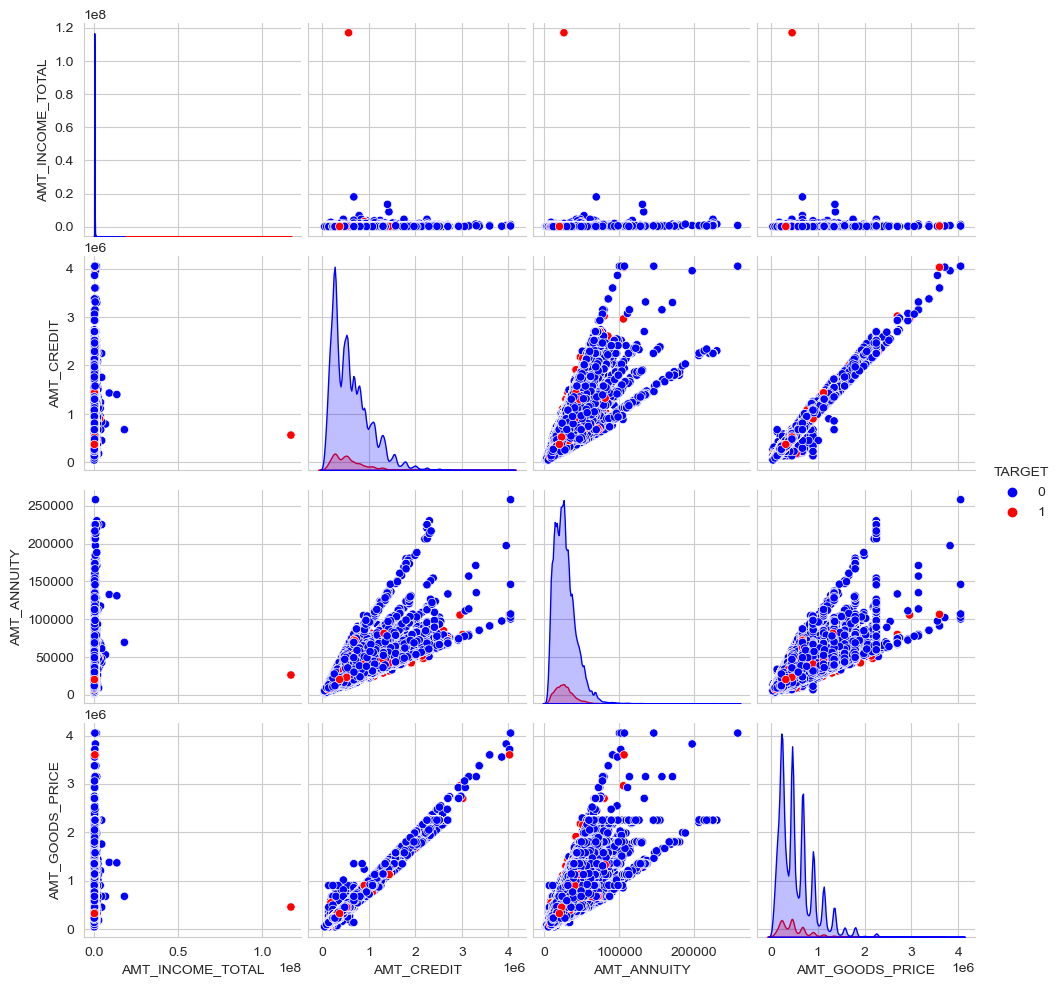

In [101]:
amt = application_data[[ 'AMT_INCOME_TOTAL','AMT_CREDIT',
                         'AMT_ANNUITY', 'AMT_GOODS_PRICE',"TARGET"]]
amt = amt[(amt['AMT_GOODS_PRICE'].notnull()) & (amt['AMT_ANNUITY'].notnull())]
sns.pairplot(amt,hue="TARGET",palette=["b","r"])
plt.show()

#AMT_GOODS_PRICE and AMT_CREDIT has strong linear relaationship
#AMT_ANNUITY and AMT_CREDIT has also made linear relationship
#AMT_ANNUITY and AMT_GOODS_PRIVE has also made a significant linear relationship with each other

Distribution of suite type

NAME_TYPE_SUITE - Who was accompanying client when he was applying for the loan.

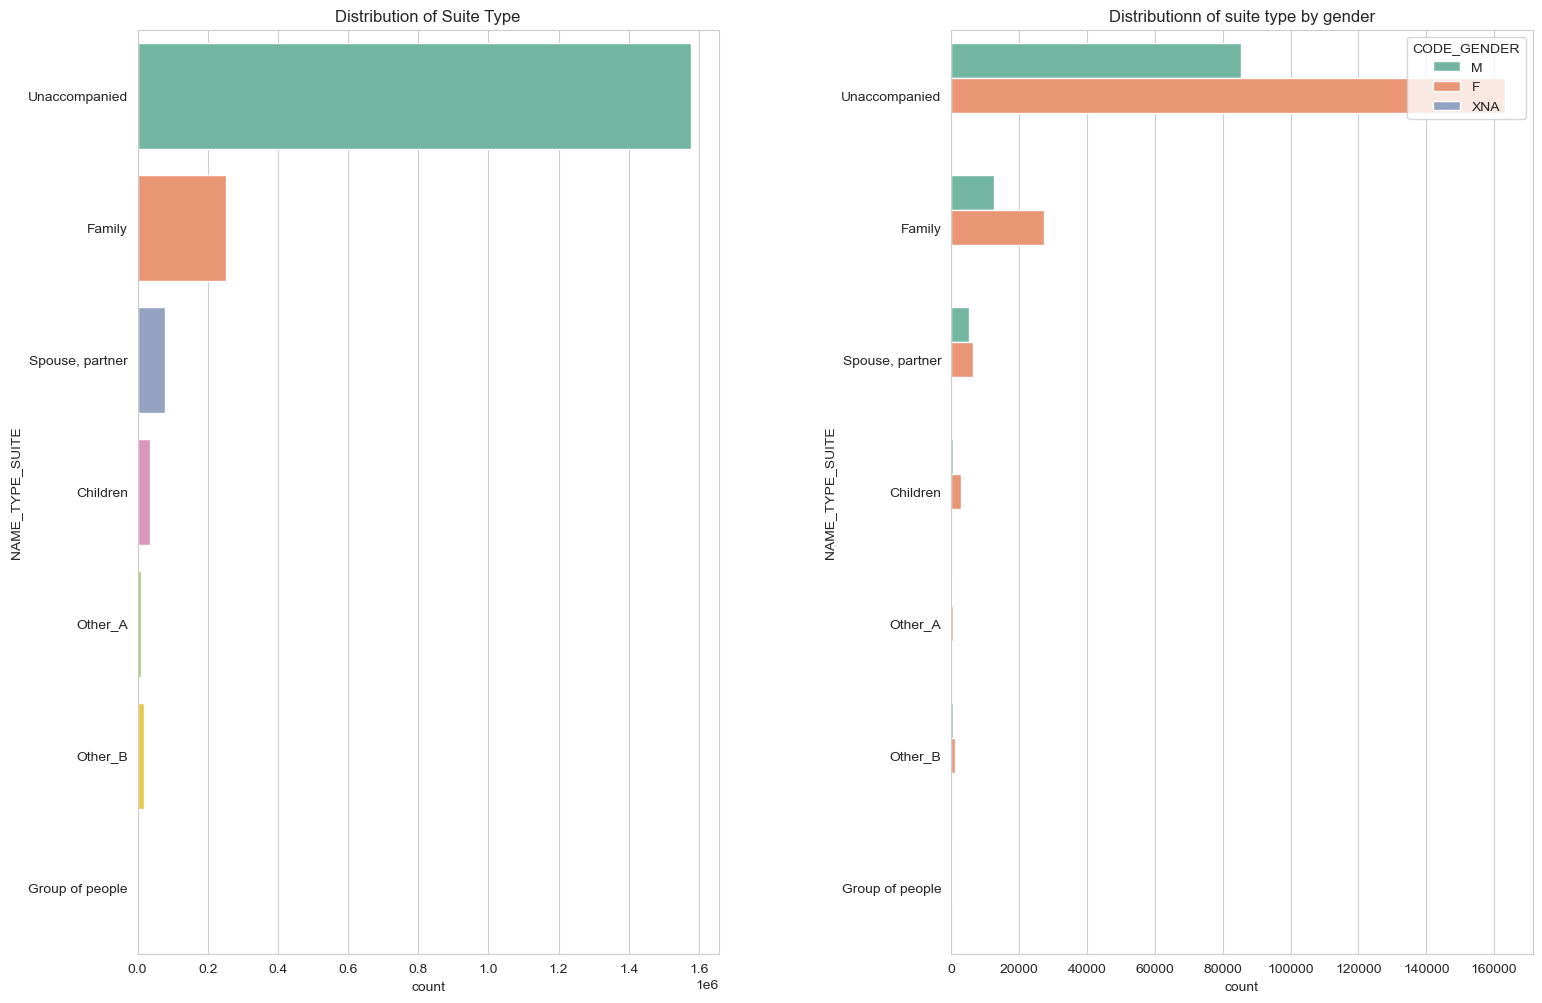

In [102]:
plt.figure(figsize=(18,12))
plt.subplot(121)
sns.countplot(y = data['NAME_TYPE_SUITE'],
             palette="Set2")
plt.title("Distribution of Suite Type")

plt.subplot(122)
sns.countplot(y = data['NAME_TYPE_SUITE'],
             hue = data['CODE_GENDER'],palette="Set2")
plt.title("Distributionn of suite type by gender")
plt.subplots_adjust(wspace = .4)

#Most of the people having no company and from the unccompanied one majority of them are females

Distribution of client income type

NAME_INCOME_TYPE Clients income type (businessman, working, maternity leave,…)

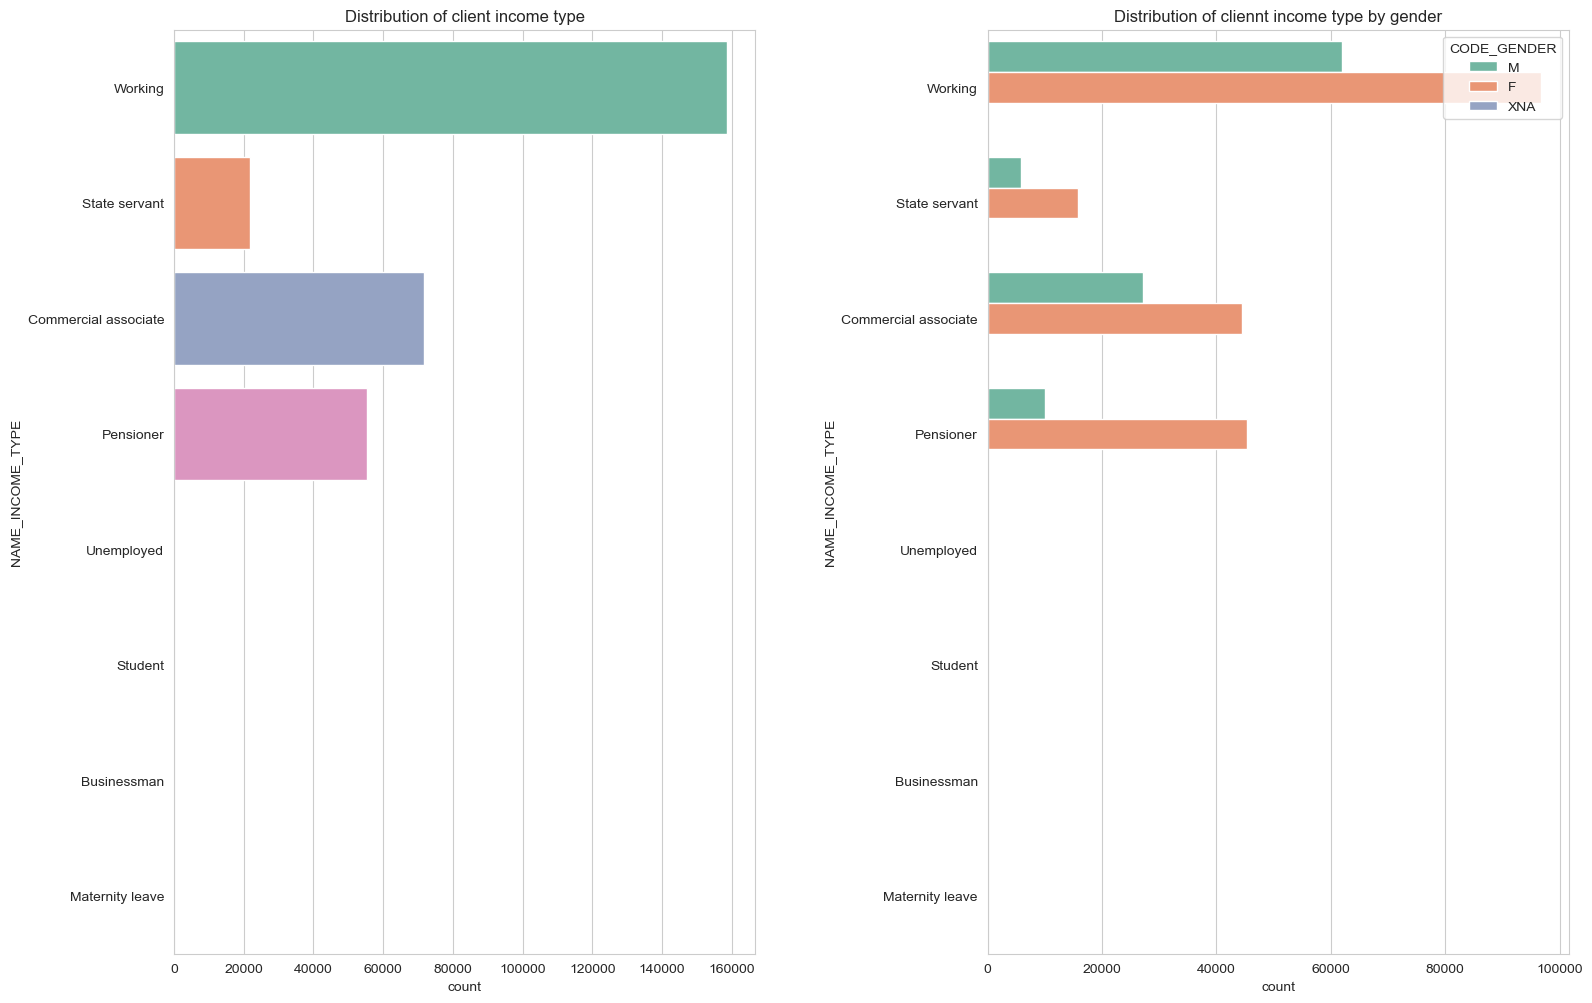

In [103]:
plt.figure(figsize=(18,12))
plt.subplot(121)
sns.countplot(y=data["NAME_INCOME_TYPE"],
             palette = "Set2")
plt.title("Distribution of client income type")

plt.subplot(122)
sns.countplot(y = data["NAME_INCOME_TYPE"],
             hue = data["CODE_GENDER"],
             palette="Set2")
plt.title("Distribution of cliennt income type by gender")
plt.subplots_adjust(wspace=0.4)

#Out of all the applicants majority of them are working and in that majority most of them are females
#Followed by that the applicants are commercial associate and in that majority are of them are females
#For all the income type people all the majority people are of female gender.

Distribution of Education type by loan repayment status

NAME_EDUCATION_TYPE Level of highest education the client achieved.

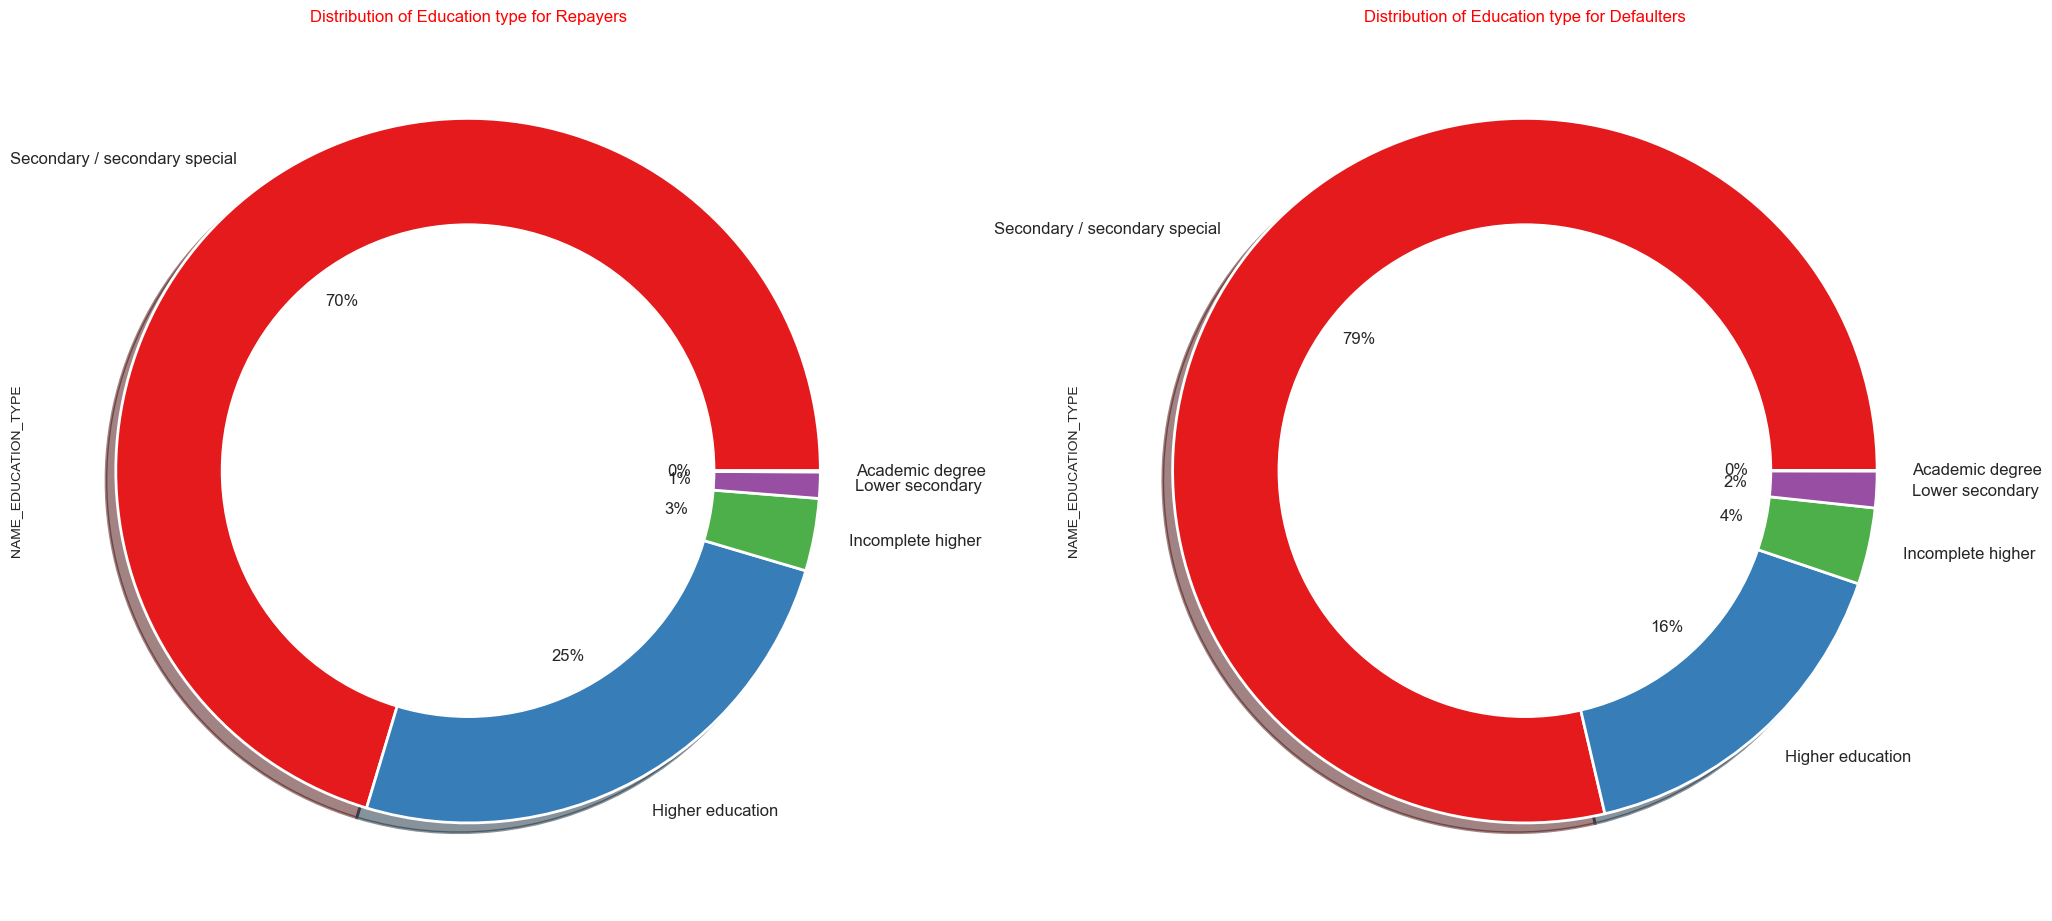

In [142]:
plt.figure(figsize=(25,25))
plt.subplot(121)
upd_applicationn_data[upd_applicationn_data["TARGET"]==0]["NAME_EDUCATION_TYPE"].value_counts().plot.pie(fontsize = 12,autopct = "%1.0F%%",
                                                                                colors = sns.color_palette("Set1"),
                                                                                wedgeprops = {"linewidth":2,"edgecolor":"white"},shadow=True)
circ = plt.Circle((0,0),0.7,color = "white")
plt.gca().add_artist(circ)
plt.title("Distribution of Education type for Repayers",color="r")

plt.subplot(122)
application_data[application_data["TARGET"]==1]["NAME_EDUCATION_TYPE"].value_counts().plot.pie(fontsize=12,autopct = "%1.0f%%",
                                                                                                 colors = sns.color_palette("Set1"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)
circ = plt.Circle((0,0),.7,color="white")
plt.gca().add_artist(circ)
plt.title("Distribution of Education type for Defaulters",color="r")
plt.show()

#Majority people are having secondary degree irrespective of the defaulter or non defaulter
#From the majority the repayer people who have passed secondaary are 9% less than that of defaulters people

Average Earnings by different professions and education types

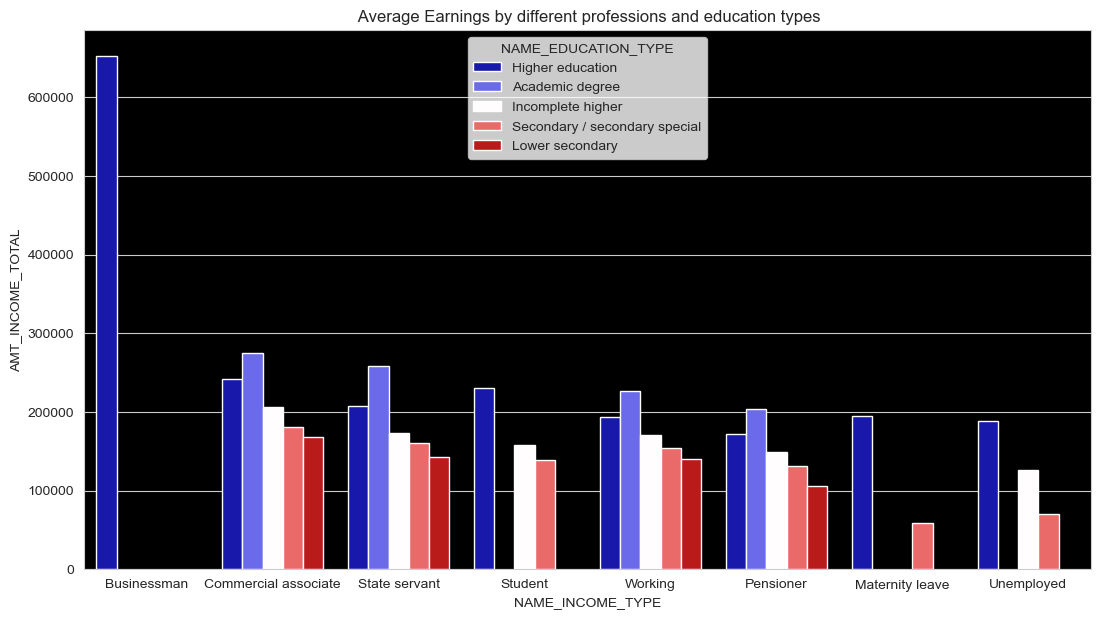

In [105]:
edu = data.groupby(["NAME_EDUCATION_TYPE","NAME_INCOME_TYPE"])["AMT_INCOME_TOTAL"].mean().reset_index().sort_values(by = "AMT_INCOME_TOTAL",ascending = False)
fig = plt.figure(figsize=(13,7))
ax = sns.barplot('NAME_INCOME_TYPE','AMT_INCOME_TOTAL',data=edu,hue='NAME_EDUCATION_TYPE',palette="seismic")
ax.set_facecolor("k")
plt.title(" Average Earnings by different professions and education types")
plt.show()

#The maximum income is coming from businessman who is having a higher education
#Followed by this the income type coming from commercial associate who has an academic degree

Distribution of Education type by loan repayment status
NAME_FAMILY_STATUS - Family status of the client

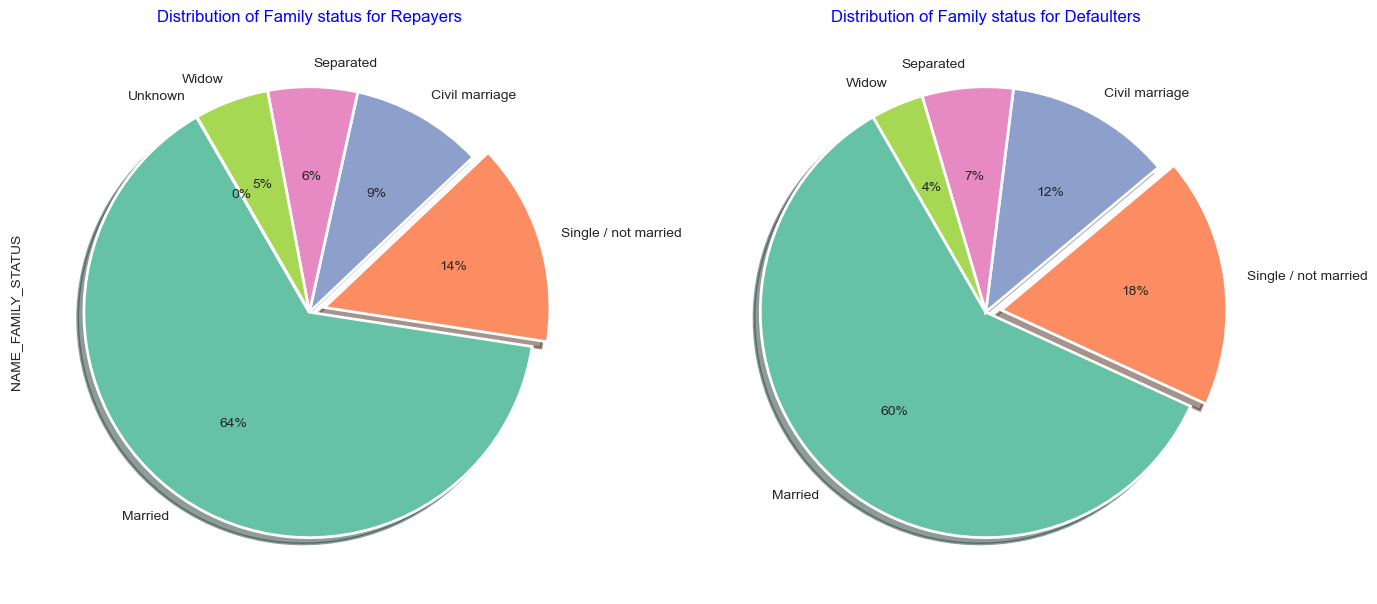

In [106]:
plt.figure(figsize=(16,8))
plt.subplot(121)
application_data[application_data["TARGET"]==0]["NAME_FAMILY_STATUS"].value_counts().plot.pie(autopct = "%1.0f%%",
                                                             startangle=120,colors = sns.color_palette("Set2",7),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True,explode=[0,.07,0,0,0,0])

plt.title("Distribution of Family status for Repayers",color="b")

plt.subplot(122)
application_data[application_data["TARGET"]==1]["NAME_FAMILY_STATUS"].value_counts().plot.pie(autopct = "%1.0f%%",
                                                    startangle=120,colors = sns.color_palette("Set2",7),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True,explode=[0,.07,0,0,0])


plt.title("Distribution of Family status for Defaulters",color="b")
plt.ylabel("")
plt.show()

#Most of the people who are defaulters and non defaulters are married whereas
#Single People are more in defaulters list than repayer list

Distribution of Housing type by loan repayment status

NAME_HOUSING_TYPE - What is the housing situation of the client (renting, living with parents, ...)

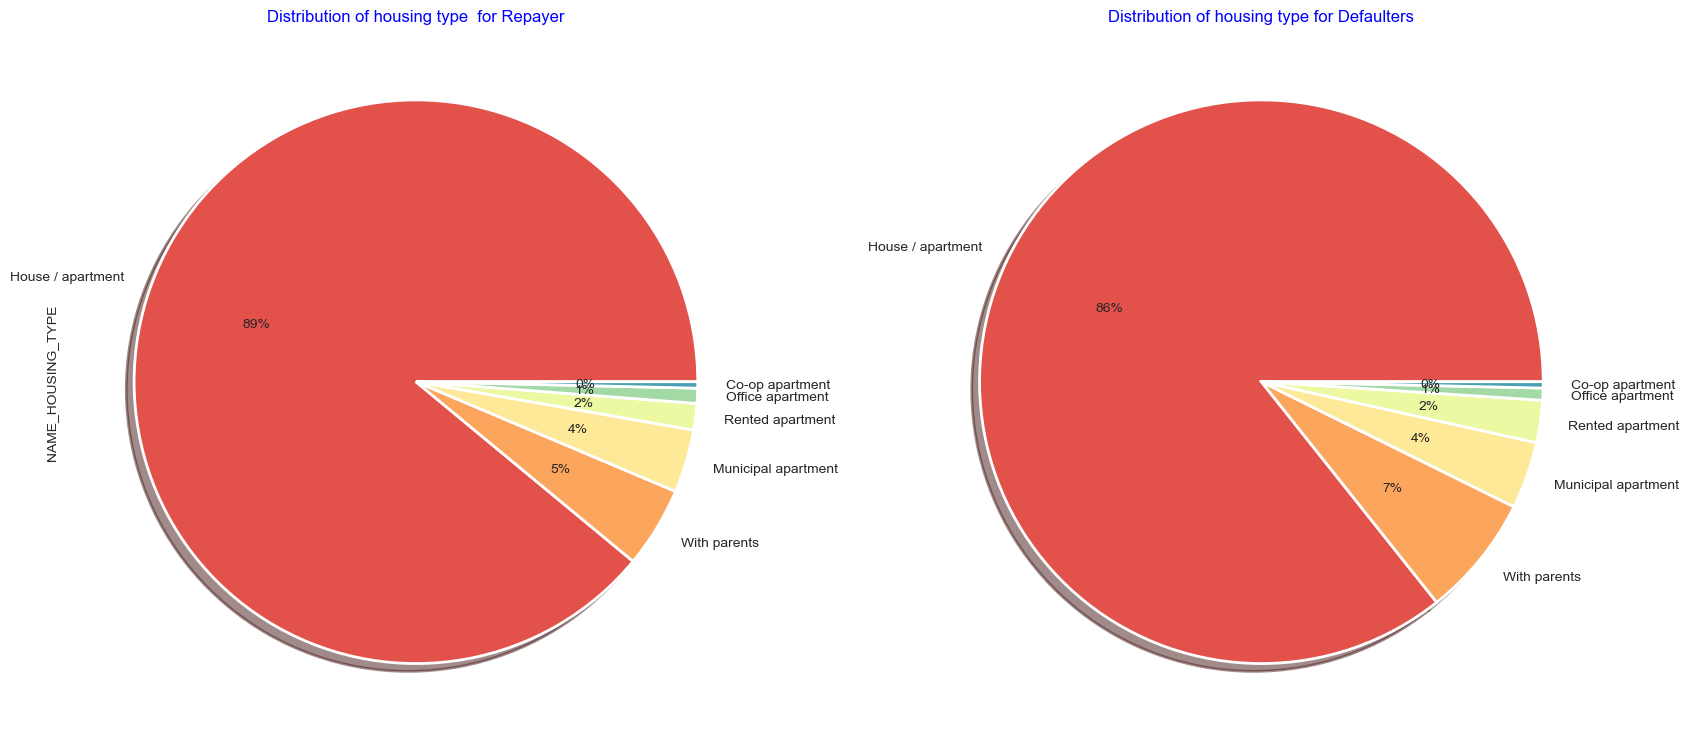

In [107]:
plt.figure(figsize=(20,20))
plt.subplot(121)
application_data[application_data["TARGET"]==0]["NAME_HOUSING_TYPE"].value_counts().plot.pie(autopct = "%1.0f%%",fontsize=10,
                                                             colors = sns.color_palette("Spectral"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)

plt.title("Distribution of housing type  for Repayer",color="b")

plt.subplot(122)
application_data[application_data["TARGET"]==1]["NAME_HOUSING_TYPE"].value_counts().plot.pie(autopct = "%1.0f%%",fontsize=10,
                                                    colors = sns.color_palette("Spectral"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)


plt.title("Distribution of housing type for Defaulters",color="b")
plt.ylabel("")
plt.show()
#Mojrity of the people irrespective of defaulters and non defaulters are having Home

Client's age

DAYS_BIRTH - Client's age in days at the time of application.

Text(0.5, 1.0, 'Age Distribution of defaulters')

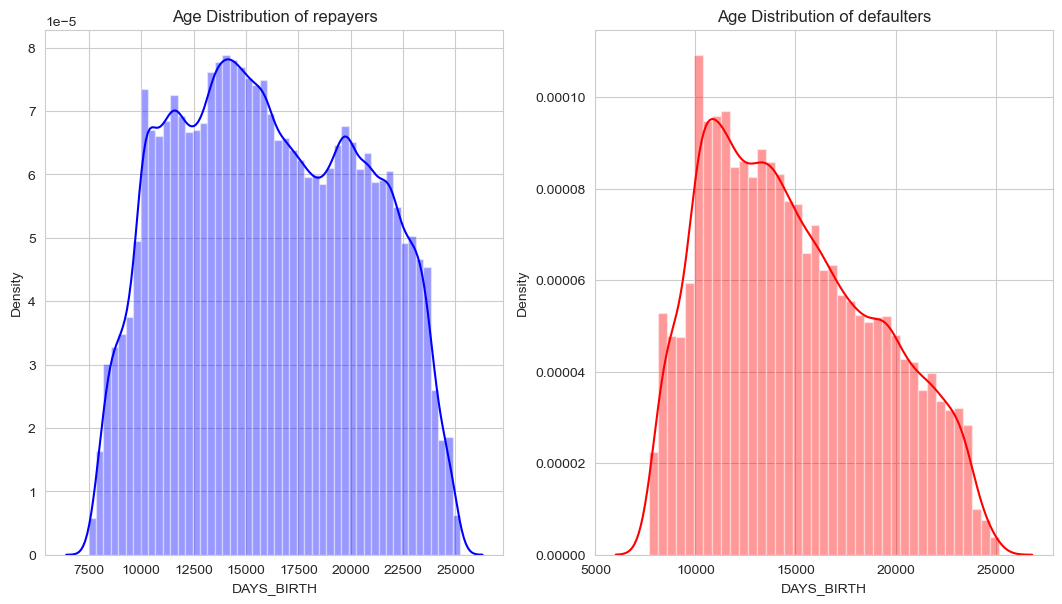

In [108]:
fig = plt.figure(figsize=(13,15))

plt.subplot(221)
sns.distplot(upd_applicationn_data[upd_applicationn_data["TARGET"]==0]["DAYS_BIRTH"],color="b")
plt.title("Age Distribution of repayers")w

plt.subplot(222)
sns.distplot(upd_applicationn_data[upd_applicationn_data["TARGET"]==1]["DAYS_BIRTH"],color="r")
plt.title("Age Distribution of defaulters")

#Age is normally distributed

In [109]:
target_0 = upd_applicationn_data[upd_applicationn_data["TARGET"]==0]["DAYS_BIRTH"]
target_1 = upd_applicationn_data[upd_applicationn_data["TARGET"]==1]["DAYS_BIRTH"]

print("The Repayers mean age :",target_0.mean())
print("The Defaulters mean age :" ,target_1.mean())

#The defaulters mean age is less than the repayers age
#Signifoes the lower age who are having less income are taking more loan which thet find it difficult to pay

The Repayers mean age : 16138.176397133215
The Defaulters mean age : 14884.82807653575


Distribution of registration days for target variable.

DAYS_REGISTRATION How many days before the application did client change his registration

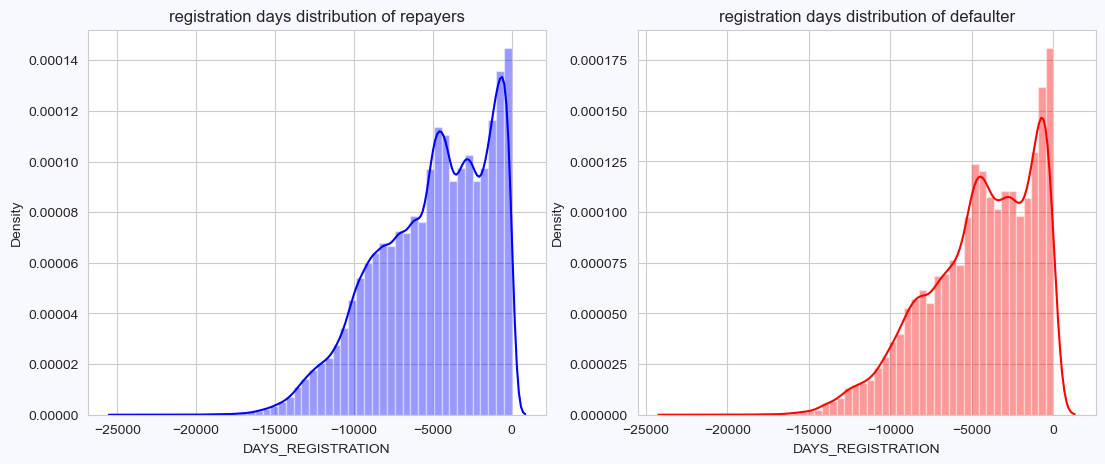

In [110]:
fig = plt.figure(figsize=(13,5))

plt.subplot(121)
sns.distplot(upd_applicationn_data[upd_applicationn_data["TARGET"]==0]["DAYS_REGISTRATION"],color="b")
plt.title("registration days distribution of repayers")

plt.subplot(122)
sns.distplot(upd_applicationn_data[upd_applicationn_data["TARGET"]==1]["DAYS_REGISTRATION"],color="r")
plt.title("registration days distribution of defaulter")

fig.set_facecolor("ghostwhite")

#Defaulters and Repayers have the same distributiion which is left skewed
#From the distribution we can undertsand that majority of the people have done
#changes in registration on an average of 5000 days before the application.

Distribution in contact information provided by client 

FLAG_MOBIL - Did client provide mobile phone (1=YES, 0=NO)

FLAG_EMP_PHONE - Did client provide work phone (1=YES, 0=NO)

FLAG_WORK_PHONE - Did client provide home phone (1=YES, 0=NO)

FLAG_CONT_MOBILE - Was mobile phone reachable (1=YES, 0=NO)

FLAG_PHONE - Did client provide home phone (1=YES, 0=NO)

FLAG_EMAIL - Did client provide email (1=YES, 0=NO)

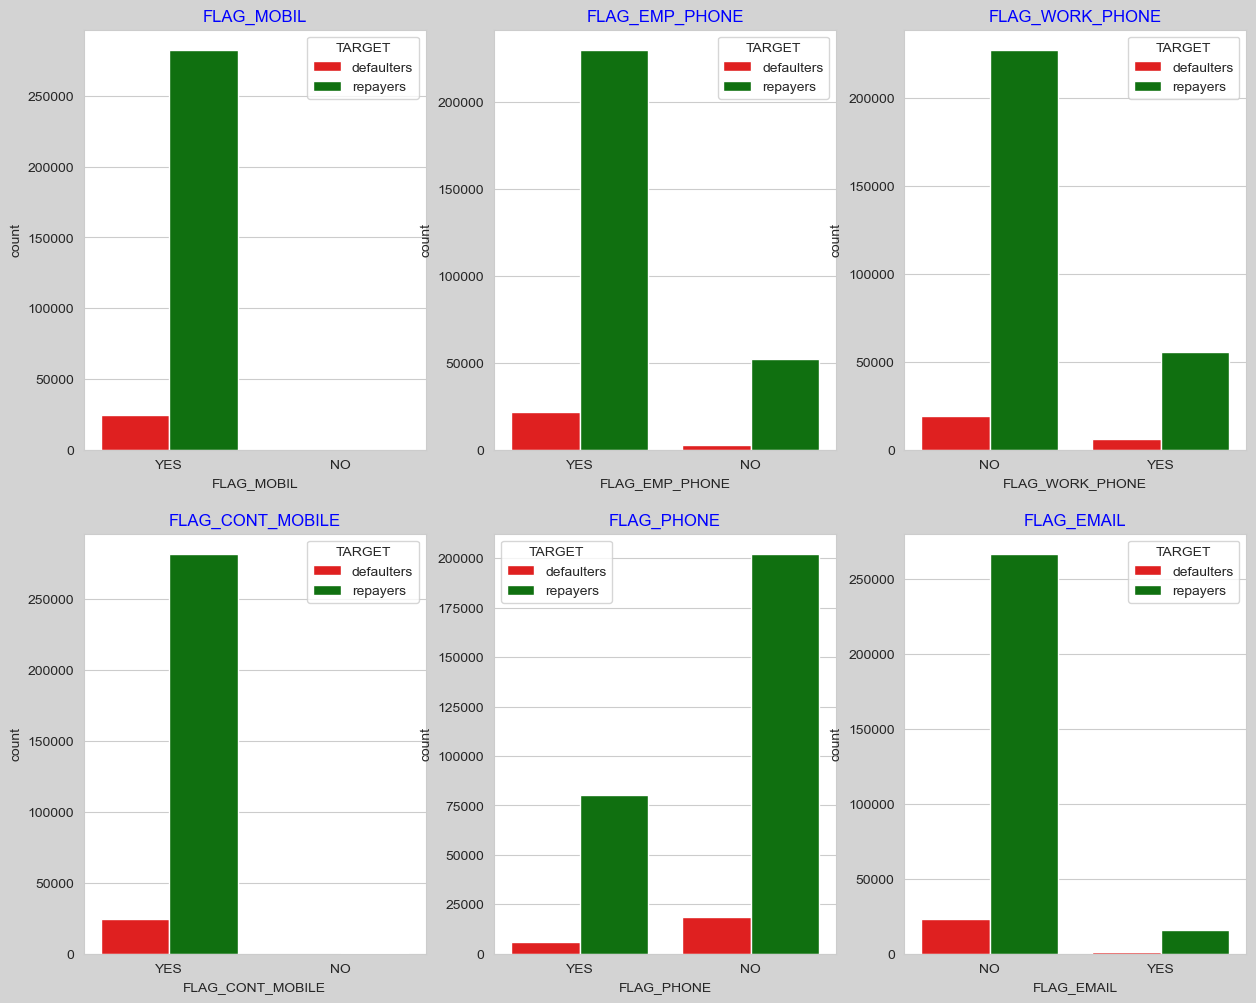

In [111]:
x = application_data[['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL',"TARGET"]]
x["TARGET"] = x["TARGET"].replace({0:"repayers",1:"defaulters"})
x  = x.replace({1:"YES",0:"NO"})

cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL']
length = len(cols)

fig = plt.figure(figsize=(15,12))
fig.set_facecolor("lightgrey")

for i,j in itertools.zip_longest(cols,range(length)):
    plt.subplot(2,3,j+1)
    sns.countplot(x[i],hue=x["TARGET"],palette=["r","g"])
    plt.title(i,color="b")

#Flag Mobile = The one who provided mobile are having majority repayers
#Flag Emp mobile = The one who provided work phone are having majority repayers and the same happens for FLAG_WORK_PHONE
#Flag Phone = The client who doesn't provide home phones are majorly repayers

Distribution of registration days for target variable.

REGION_RATING_CLIENT - Home credit rating of the region where client lives (1,2,3).

REGION_RATING_CLIENT_W_CITY - Home credit rating of the region where client lives with taking city into account (1,2,3). Percentage of defaulters are less in 1-rated regions compared to repayers.

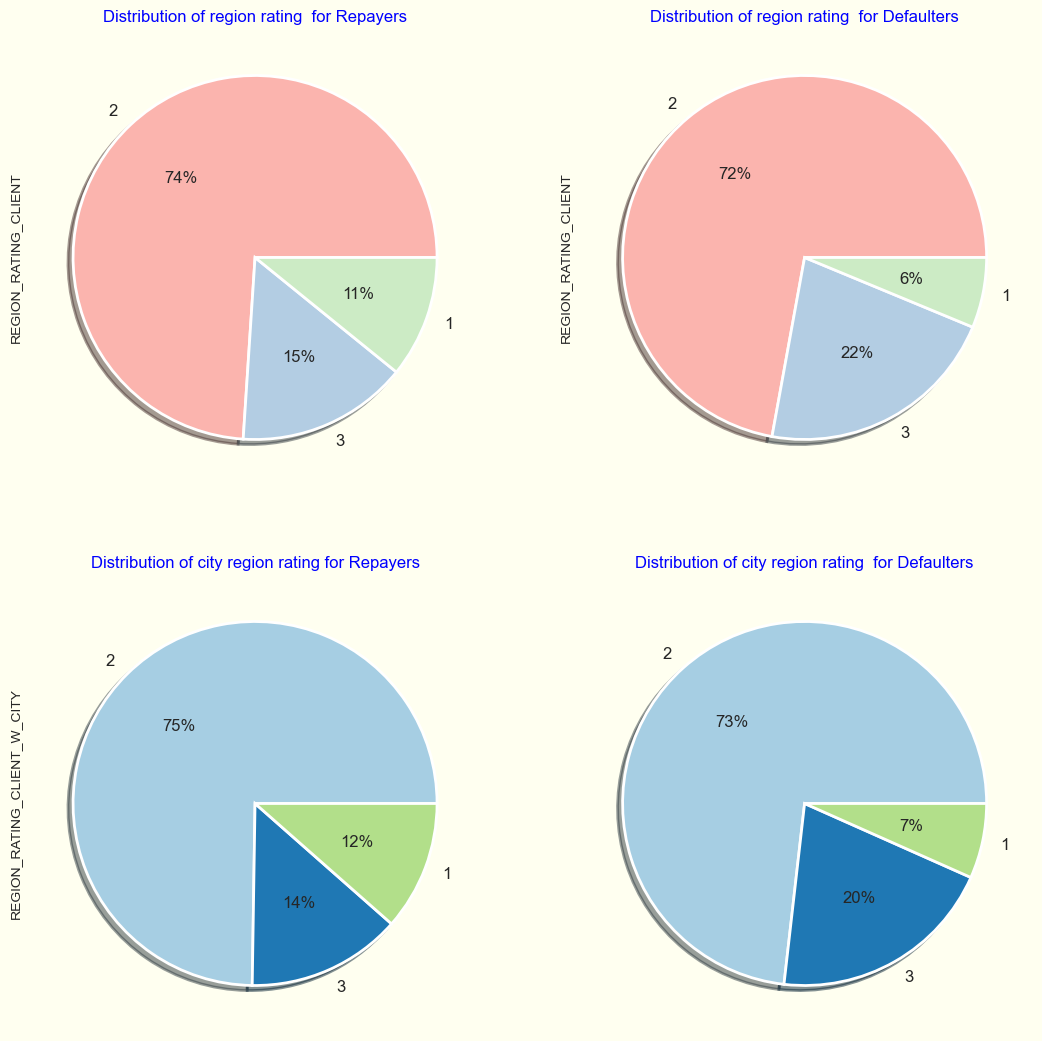

In [112]:
fig = plt.figure(figsize=(13,13))
plt.subplot(221)
upd_applicationn_data[upd_applicationn_data["TARGET"]==0]["REGION_RATING_CLIENT"].value_counts().plot.pie(autopct = "%1.0f%%",fontsize = 12,
                                                                colors = sns.color_palette("Pastel1"),
                                                                wedgeprops = {"linewidth":2,"edgecolor":"white"},shadow = True)
plt.title("Distribution of region rating  for Repayers",color="b")

plt.subplot(222)
upd_applicationn_data[upd_applicationn_data["TARGET"]==1]["REGION_RATING_CLIENT"].value_counts().plot.pie(autopct = "%1.0f%%",fontsize = 12,
                                                                colors = sns.color_palette("Pastel1"),
                                                                wedgeprops = {"linewidth":2,"edgecolor":"white"},shadow = True)
plt.title("Distribution of region rating  for Defaulters",color="b")

plt.subplot(223)
application_data[upd_applicationn_data["TARGET"]==0]["REGION_RATING_CLIENT_W_CITY"].value_counts().plot.pie(autopct = "%1.0f%%",fontsize=12,
                                                             colors = sns.color_palette("Paired"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)

plt.title("Distribution of city region rating for Repayers",color="b")

plt.subplot(224)
application_data[upd_applicationn_data["TARGET"]==1]["REGION_RATING_CLIENT_W_CITY"].value_counts().plot.pie(autopct = "%1.0f%%",fontsize=12,
                                                    colors = sns.color_palette("Paired"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)


plt.title("Distribution of city region rating  for Defaulters",color="b")

plt.ylabel("")
fig.set_facecolor("ivory")

#Percentage of Repayers are significantly less in 3 rated city compared to defaulters
#Percentage of Defaulters are signifiicantly less in 1 rated city compared to the repayers

Peak days and hours for applying loans (defaulters vs repayers)

WEEKDAY_APPR_PROCESS_START - On which day of the week did the client apply for the loan.

HOUR_APPR_PROCESS_START - Approximately at what hour did the client apply for the loan.

In [146]:
day = upd_applicationn_data.groupby("TARGET").agg({"WEEKDAY_APPR_PROCESS_START":"value_counts"})
day = day.rename(columns={"WEEKDAY_APPR_PROCESS_START":"value_counts"})
day = day.reset_index()
day_0 = day[:7]
day_1 = day[7:]
day_0

,TARGET,WEEKDAY_APPR_PROCESS_START,value_counts
0,0,TUESDAY,49400
1,0,WEDNESDAY,47696
2,0,MONDAY,46780
3,0,THURSDAY,46493
4,0,FRIDAY,46237
5,0,SATURDAY,31182
6,0,SUNDAY,14898


Text(0.5, 1.0, 'Peak days for applying loans (defaulters vs repayers)')

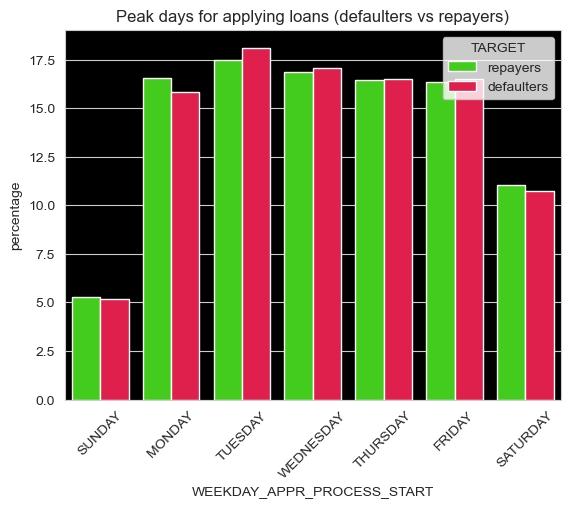

In [113]:
day = upd_applicationn_data.groupby("TARGET").agg({"WEEKDAY_APPR_PROCESS_START":"value_counts"})
day = day.rename(columns={"WEEKDAY_APPR_PROCESS_START":"value_counts"})
day = day.reset_index()
day_0 = day[:7]
day_1 = day[7:]
day_0["percentage"] = day_0["value_counts"]*100/day_0["value_counts"].sum()
day_1["percentage"] = day_1["value_counts"]*100/day_1["value_counts"].sum()
days = pd.concat([day_0,day_1],axis=0)
days["TARGET"] = days["TARGET"].replace({1: "defaulters", 0: "repayers"})
order = ['SUNDAY', 'MONDAY','TUESDAY', 'WEDNESDAY','THURSDAY', 'FRIDAY', 'SATURDAY']
ax= sns.barplot("WEEKDAY_APPR_PROCESS_START","percentage",data=days,
                hue="TARGET",order=order,palette="prism")
ax.set_facecolor("k")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("Peak days for applying loans (defaulters vs repayers)")
#Tuesday is the most favourable day for repayers and defaulters to apply for loan where
#percentage of defaulters is more than repayeers in tuesday

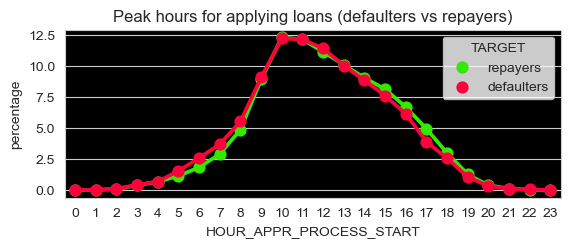

In [114]:
hr = upd_applicationn_data.groupby("TARGET").agg({"HOUR_APPR_PROCESS_START":"value_counts"})
hr = hr.rename(columns={"HOUR_APPR_PROCESS_START":"value_counts"}).reset_index()
hr_0 = hr[hr["TARGET"]==0]
hr_1 = hr[hr["TARGET"]==1]
hr_0["percentage"] = hr_0["value_counts"]*100/hr_0["value_counts"].sum()
hr_1["percentage"] = hr_1["value_counts"]*100/hr_1["value_counts"].sum()
hrs = pd.concat([hr_0,hr_1],axis=0)
hrs["TARGET"] = hrs["TARGET"].replace({1:"defaulters",0:"repayers"})
hrs = hrs.sort_values(by="HOUR_APPR_PROCESS_START",ascending=True)

plt.subplot(212)
ax1 = sns.pointplot("HOUR_APPR_PROCESS_START","percentage",
                    data=hrs,hue="TARGET",palette="prism")
ax1.set_facecolor("k")
ax1.set_title("Peak hours for applying loans (defaulters vs repayers)")
fig.set_facecolor("snow")

## 6 to 12 O clock percentage is the peak time where both repayers and defaulters apply together

Distribution in organization types for repayers and defaulters

ORGANIZATION_TYPE - Type of organization where client works.

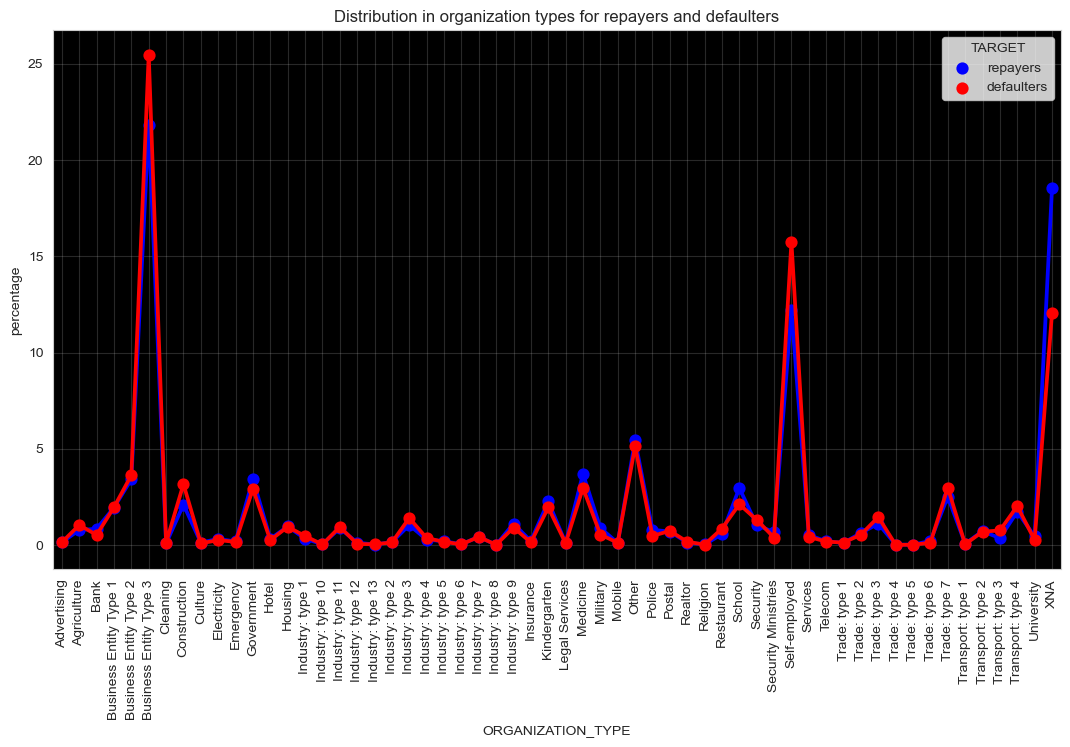

In [115]:
org = upd_applicationn_data.groupby("TARGET").agg({"ORGANIZATION_TYPE":"value_counts"})
org = org.rename(columns = {"ORGANIZATION_TYPE":"value_counts"}).reset_index()
org_0=org[org["TARGET"]==0]
org_1=org[org["TARGET"]==1]
org_0["percentage"] = org_0["value_counts"]*100/org_0["value_counts"].sum()
org_1["percentage"] = org_1["value_counts"]*100/org_1["value_counts"].sum()
organization = pd.concat([org_0,org_1],axis=0)
organization = organization.sort_values(by="ORGANIZATION_TYPE",ascending=True)
organization["TARGET"] = organization["TARGET"].replace({0:"repayers",1:"defaulters"})
plt.figure(figsize=(13,7))
ax = sns.pointplot("ORGANIZATION_TYPE","percentage",
                   data=organization,hue="TARGET",palette=["b","r"])
plt.xticks(rotation=90)
plt.grid(True,alpha=0.2)
ax.set_facecolor("k")
ax.set_title("Distribution in organization types for repayers and defaulters")
plt.show()

#Organisations like Business Entity type 3,construction,
#government other and self employed percetage of defaulters are higher

Number of days before application client changed phone.


DAYS_LAST_PHONE_CHANGE - How many days before application did client change phone.

Text(0.5, 1.0, 'days before application client changed phone -box plot')

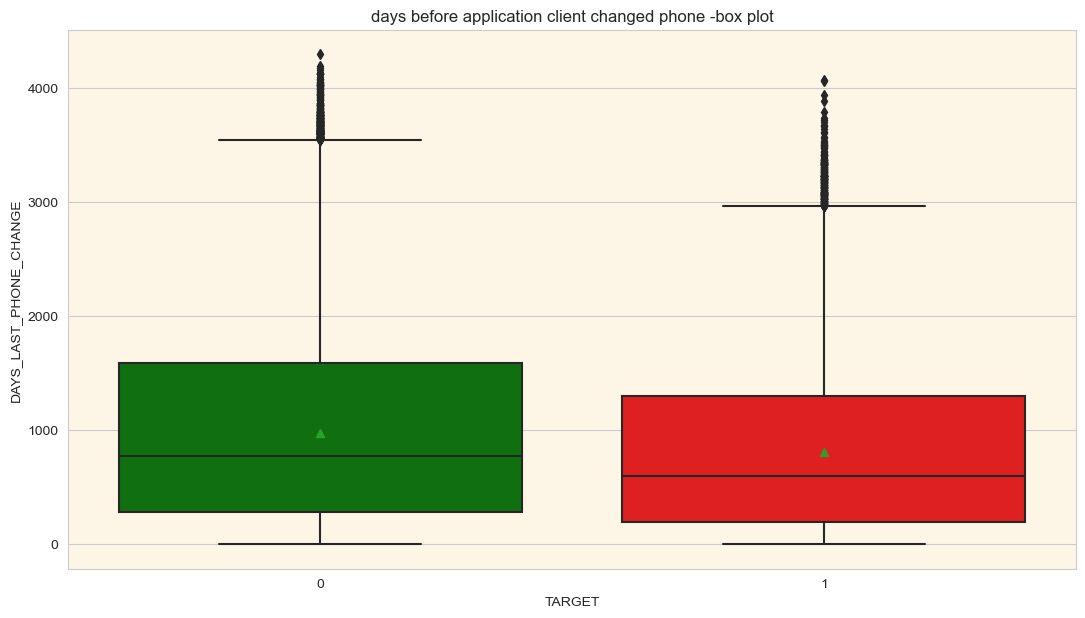

In [120]:
plt.figure(figsize=(13,7))
ax = sns.boxplot(upd_applicationn_data["TARGET"],
               upd_applicationn_data["DAYS_LAST_PHONE_CHANGE"],
               palette = ["g","r"],showmeans=True)
ax.set_facecolor("oldlace")
ax.set_title("days before application client changed phone -box plot")

#The average days before the application where cient change the phone is less in 
#the defaulters list rather than the repayers list

#It might signfies that the defaulters who know that they are going to default so they are removing the
#originial information via phone

Documents provided by the clients.

FLAG_DOCUMENT - Did client provide documents.(1,0)

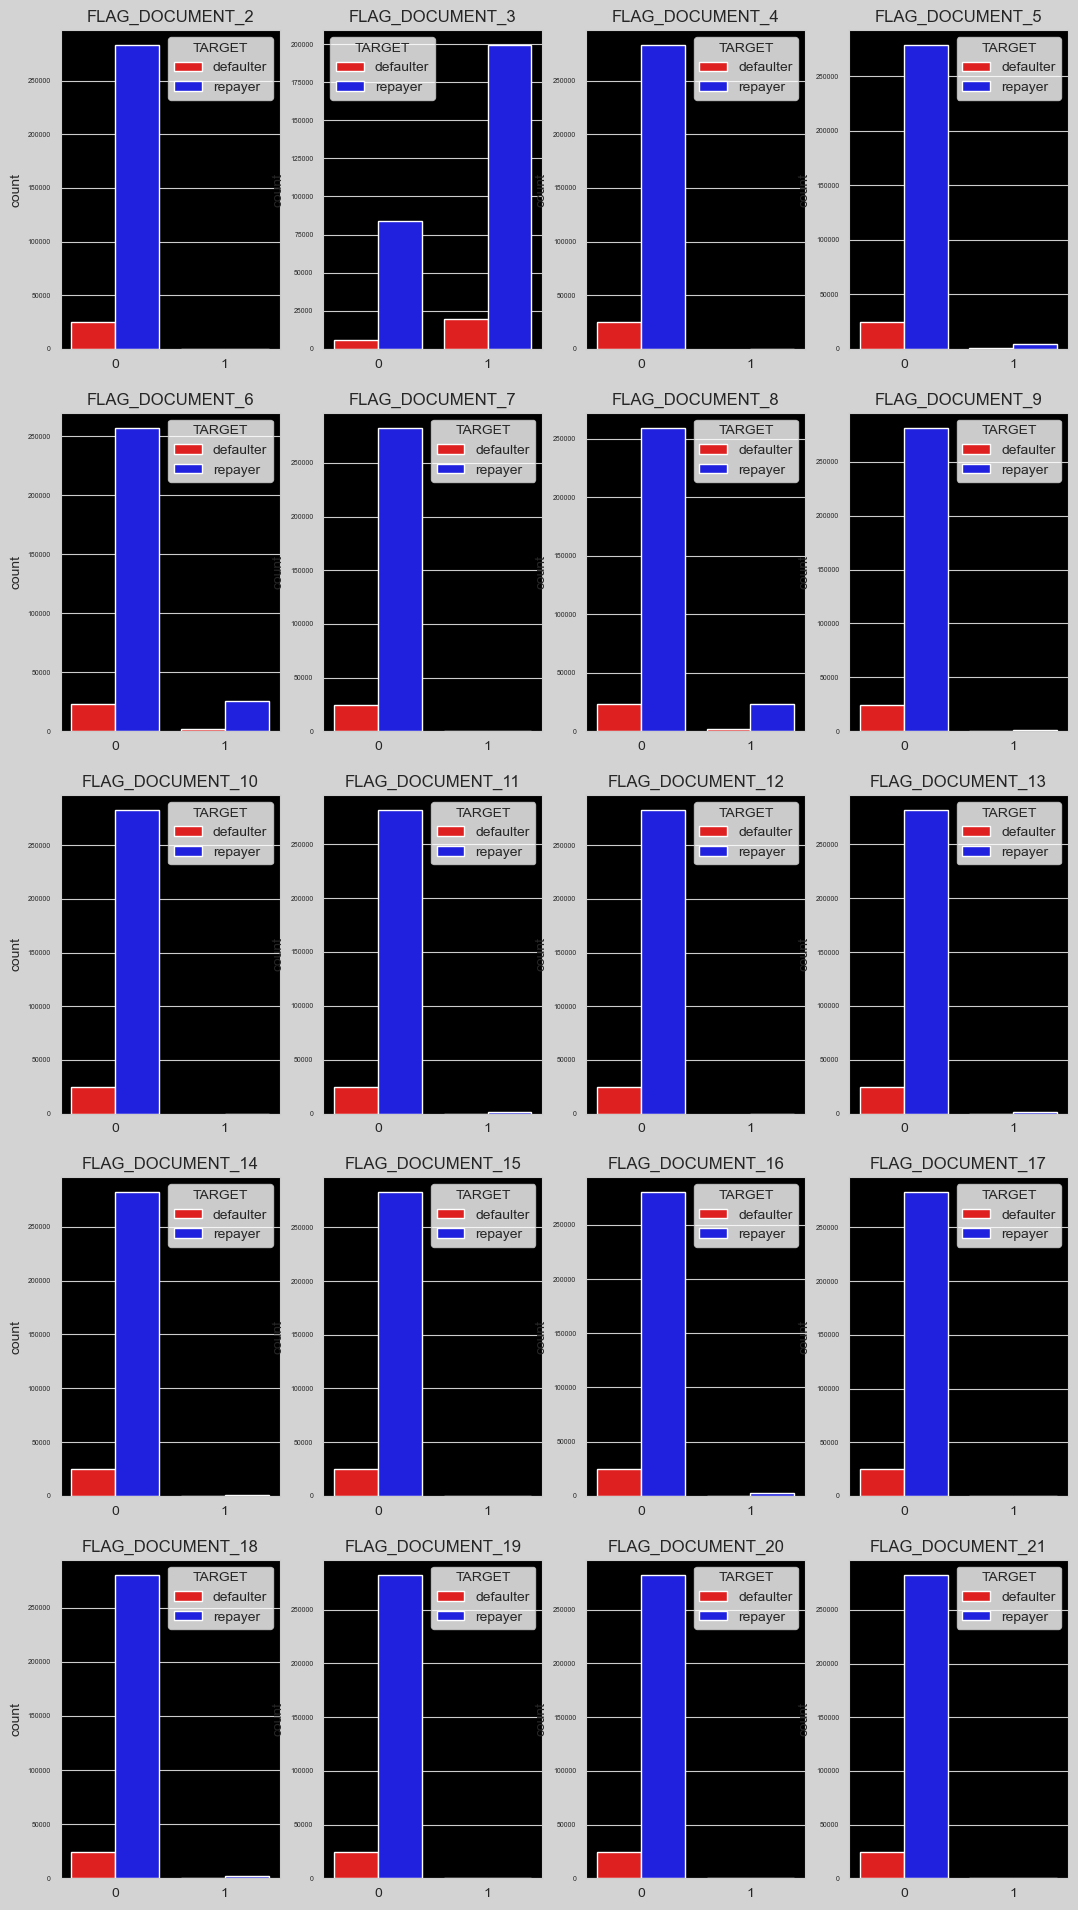

In [122]:
cols = [ 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3',
       'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
       'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
       'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15',
       'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']
df_flag = upd_applicationn_data[cols + ["TARGET"]]
length = len(cols)
df_flag["TARGET"] = df_flag["TARGET"].replace({1:"defaulter",0:"repayer"})
fig = plt.figure(figsize=(13,24))
fig.set_facecolor("lightgrey")
for i,j in itertools.zip_longest(cols,range(length)):
    plt.subplot(5,4,j+1)
    ax = sns.countplot(df_flag[i],hue = df_flag["TARGET"],
                      palette = ["r","b"])
    plt.yticks(fontsize=5)
    plt.xlabel("")
    plt.title(i)
    ax.set_facecolor("k")
#In the majority of the graphs the one who is the repayer didn't showup the documents
#But in document_3 the maximum number repayers showed this document that means it signfies document_3 is important for the sanction of loan


Current loan id having previous loan applications.

SK_ID_PREV - ID of previous credit in Home credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loan applications in Home Credit, previous application could, but not necessarily have to lead to credit).

SK_ID_CURR ID of loan in our sample.

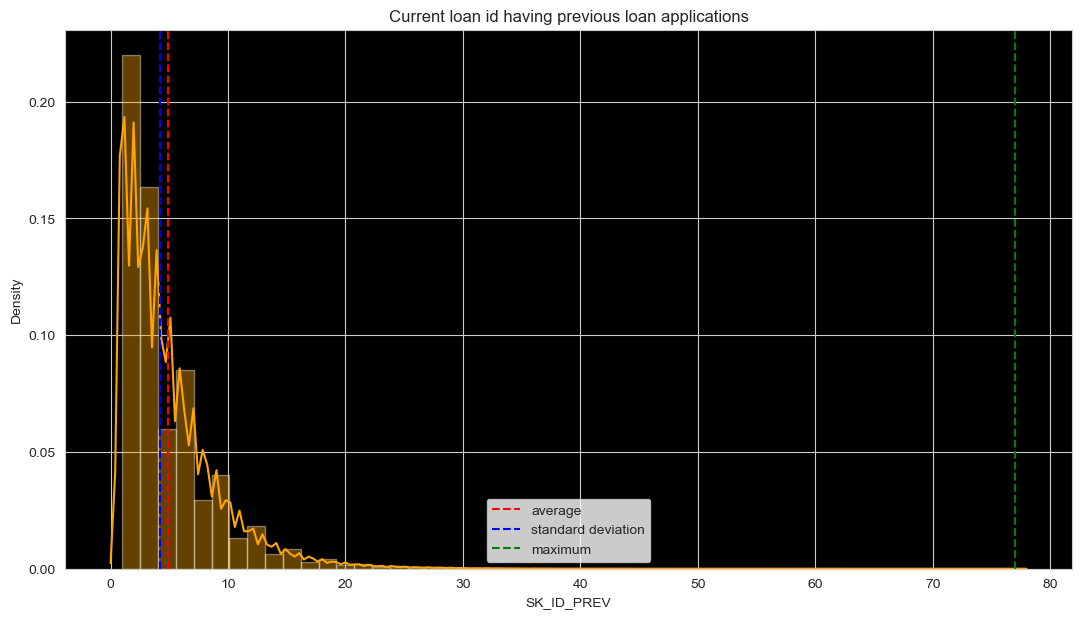

In [127]:
x = previous_application.groupby(["SK_ID_CURR"])["SK_ID_PREV"].count().reset_index()
plt.figure(figsize=(13,7))
ax = sns.distplot(x["SK_ID_PREV"],color="orange")
plt.axvline(x["SK_ID_PREV"].mean(),linestyle="dashed",color="r",label="average")
plt.axvline(x["SK_ID_PREV"].std(),linestyle="dashed",color="b",label="standard deviation")
plt.axvline(x["SK_ID_PREV"].max(),linestyle="dashed",color="g",label="maximum")
plt.legend(loc="best")
plt.title("Current loan id having previous loan applications")
ax.set_facecolor("k")

#Its is a right skewed distribution where mean > median 
#It signfies the probability of having more than 10 applications is very less
#On an average the current ID might have on an average of 4 to 5 applications

Contract types in previous applications

NAME_CONTRACT_TYPE Contract product type (Cash loan, consumer loan [POS] ,...) of the previous application.

In [128]:
pip install squarify

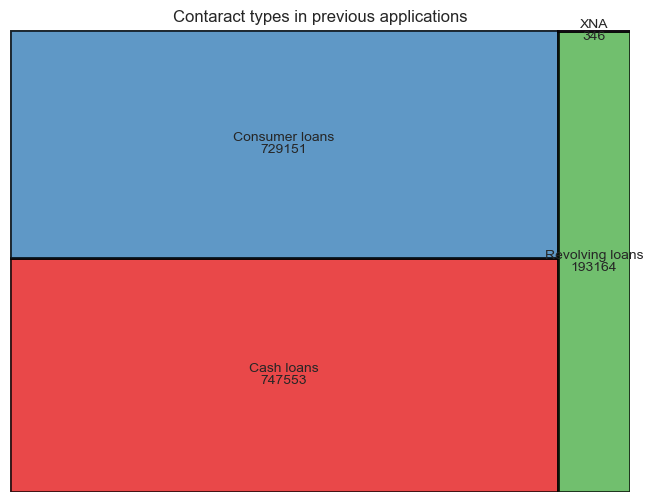

In [134]:
import squarify
cnts = previous_application["NAME_CONTRACT_TYPE"].value_counts()
plt.figure(figsize=(8,6))
squarify.plot(cnts.values,label = cnts.keys(),value = cnts.values,
              linewidth=2,edgecolor="k",alpha = 0.8,
              color = sns.color_palette("Set1"))
plt.axis("off")
plt.title("Contaract types in previous applications")
plt.show()

#Cash Loans are more than consumer loans in the previous applications

Previous loan amounts applied and loan amounts credited.

AMT_APPLICATION-For how much credit did client ask on the previous application.

AMT_CREDIT-Final credit amount on the previous application. This differs from AMT_APPLICATION in a way that the AMT_APPLICATION is the amount for which the client initially applied for, but during our approval process he could have received different amount - AMT_CREDIT.

In [148]:
upd_data_credit = previous_application[["AMT_APPLICATION","AMT_CREDIT","NAME_CONTRACT_TYPE"]]
upd_data_credit["Difference"] = upd_data_credit["AMT_APPLICATION"]-upd_data_credit["AMT_CREDIT"]
diff = upd_data_credit[upd_data_credit["Difference"]>1]
#print(upd_data_credit.shape[0],diff.shape[0])
pct_reduce_crd_apply = round(((diff.shape[0]*100)/upd_data_credit.shape[0]),2)
pct_reduce_crd_apply
#21.37% of the applications have got less amount in compared to the applications
#It might happen that the amount they applied, they are not eligible for that or
#they dont have any properties to mortgage above their applications amount
#or they are not having good credit profile

21.37

In [158]:
upd_data_credit[(upd_data_credit["AMT_APPLICATION"] != 0) & (upd_data_credit["AMT_CREDIT"] == 0)]
#This data signfies that the application for the data has been rejected
#It belogs to the revolving loans category

,AMT_APPLICATION,AMT_CREDIT,NAME_CONTRACT_TYPE,Difference
951006,45000.0,0.0,Revolving loans,45000.0


Annuity of previous application

AMT_ANNUITY - Annuity of previous application

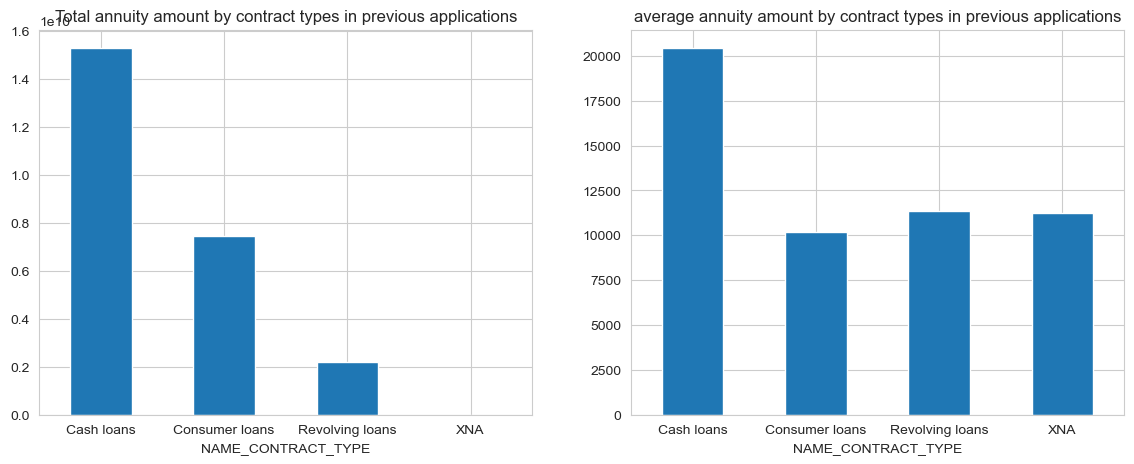

In [159]:
plt.figure(figsize=(14,5))

plt.subplot(121)
previous_application.groupby("NAME_CONTRACT_TYPE")["AMT_ANNUITY"].sum().plot(kind="bar")
plt.xticks(rotation=0)
plt.title("Total annuity amount by contract types in previous applications")

plt.subplot(122)
previous_application.groupby("NAME_CONTRACT_TYPE")["AMT_ANNUITY"].mean().plot(kind="bar")
plt.title("average annuity amount by contract types in previous applications")
plt.xticks(rotation=0)
plt.show()

#Cash Loans having the higghest annuity amount

Count of application status by application type.

NAME_CONTRACT_TYPE -Contract product type (Cash loan, consumer loan [POS] ,...) of the previous application.

NAME_CONTRACT_STATUS -Contract status (approved, cancelled, ...) of previous application.

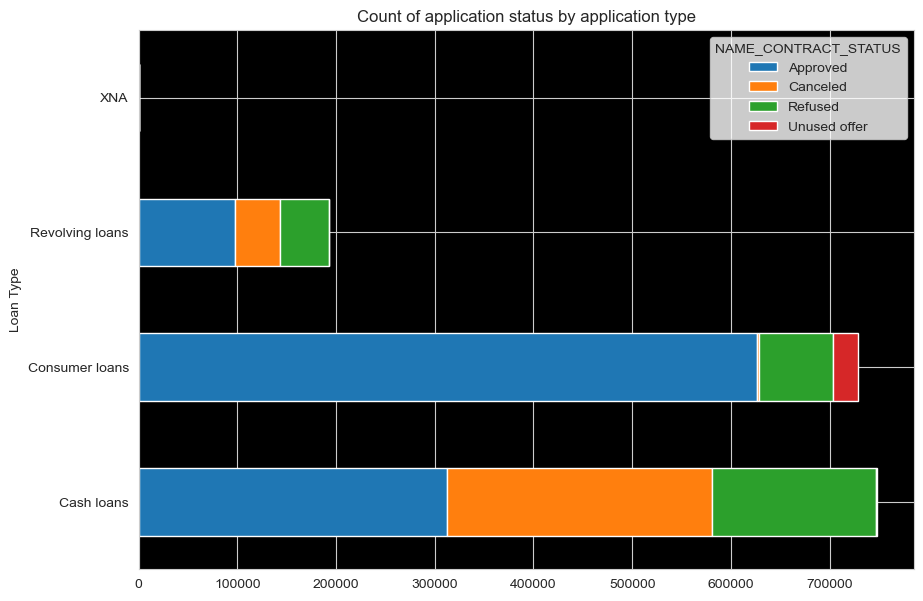

In [151]:
ax = pd.crosstab(previous_application["NAME_CONTRACT_TYPE"],
                previous_application["NAME_CONTRACT_STATUS"]).plot(kind="barh",
                figsize = (10,7),stacked=True)
plt.xticks(rotation =0)
plt.ylabel("Loan Type")
plt.title("Count of application status by application type")
ax.set_facecolor("k")
#Consumer loans are the most approved loans
#Cash Loans are the most cancelled and refused loans where the threat of defaulting might be high

Contract status by weekdays

WEEKDAY_APPR_PROCESS_START - On which day of the week did the client apply for previous application

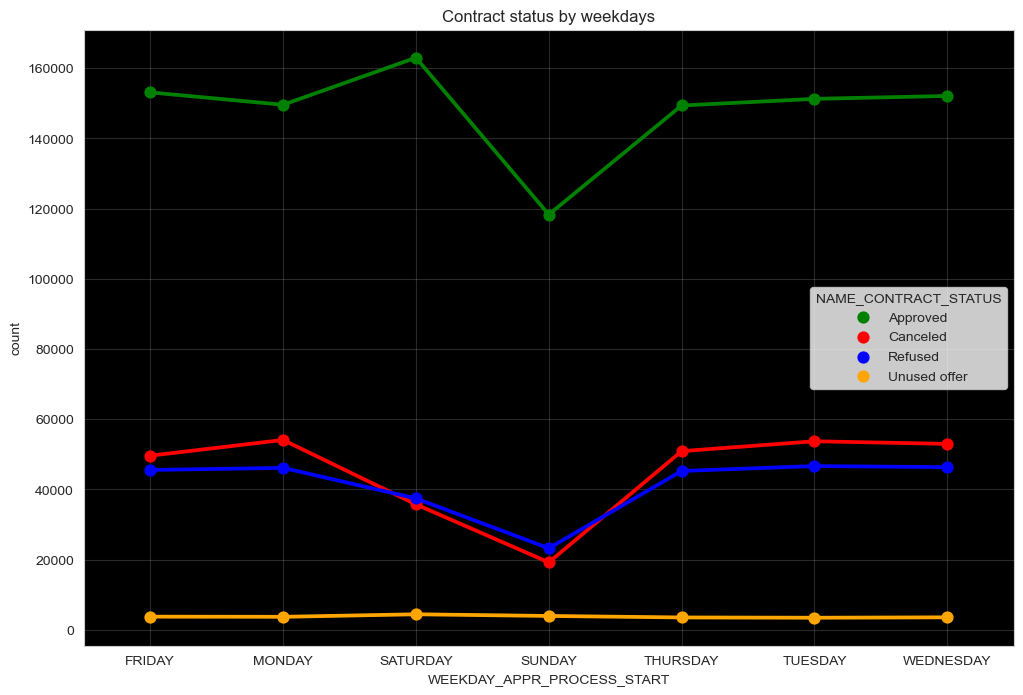

In [165]:
hr = pd.crosstab(previous_application["WEEKDAY_APPR_PROCESS_START"],previous_application["NAME_CONTRACT_STATUS"]).stack().reset_index()
plt.figure(figsize=(12,8))
ax = sns.pointplot(hr["WEEKDAY_APPR_PROCESS_START"],
                   hr[0],hue=hr["NAME_CONTRACT_STATUS"],palette=["g","r","b","orange"])
ax.set_facecolor("k")
ax.set_ylabel("count")
ax.set_title("Contract status by weekdays")
plt.grid(True,alpha=.2)

Contract status by hour of the day

HOUR_APPR_PROCESS_START - Approximately at what day hour did the client apply for the previous application.

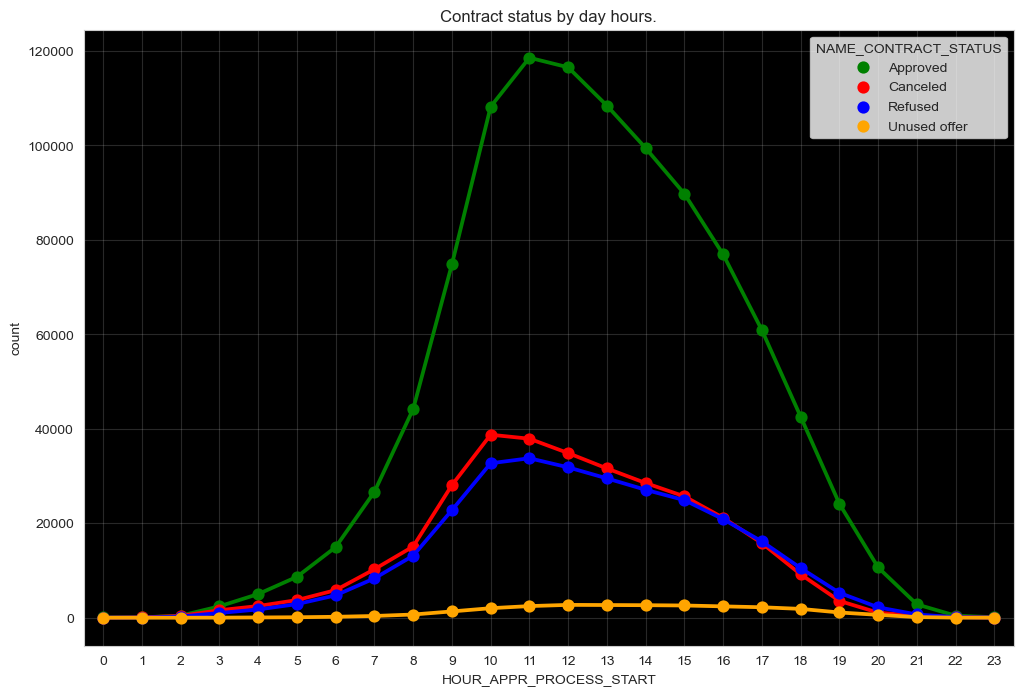

In [171]:
hr = pd.crosstab(previous_application["HOUR_APPR_PROCESS_START"],previous_application["NAME_CONTRACT_STATUS"]).stack().reset_index()
plt.figure(figsize=(12,8))
ax = sns.pointplot(hr["HOUR_APPR_PROCESS_START"],hr[0],hue=hr["NAME_CONTRACT_STATUS"],palette=["g","r","b","orange"],scale=1)
ax.set_facecolor("k")
ax.set_ylabel("count")
ax.set_title("Contract status by day hours.")
plt.grid(True,alpha=.2)

#Point to infer from the graph
#Morning 11'o clock have maximum number of approvals.
#Morning 10'o clock have maximum number of refused and cancelled contracts.

Peak hours for week days for applying loans

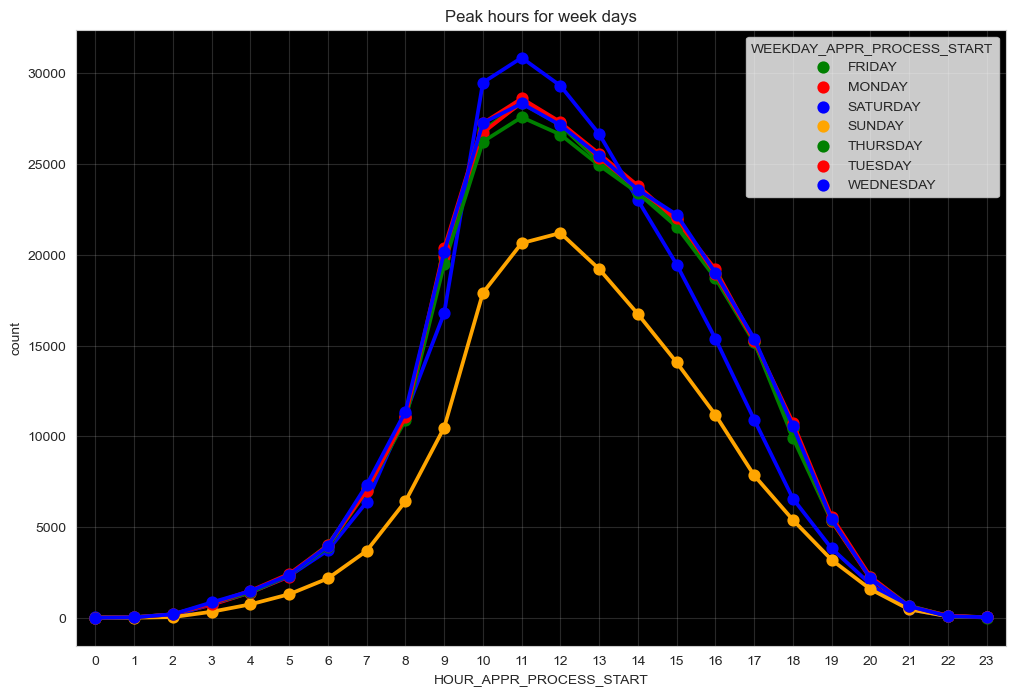

In [176]:
hr = pd.crosstab(previous_application["HOUR_APPR_PROCESS_START"],previous_application["WEEKDAY_APPR_PROCESS_START"]).stack().reset_index()
plt.figure(figsize=(12,8))
ax = sns.pointplot(hr["HOUR_APPR_PROCESS_START"],hr[0],hue=hr["WEEKDAY_APPR_PROCESS_START"],palette=["g","r","b","orange"],scale=1)
ax.set_facecolor("k")
ax.set_ylabel("count")
ax.set_title("Peak hours for week days")
plt.grid(True,alpha=.2)
#11 AM on wednesday is the peak hour for applying loans

Percentage of applications accepted,cancelled,refused and unused for different loan purposes.

NAME_CASH_LOAN_PURPOSE - Purpose of the cash loan.

NAME_CONTRACT_STATUS - Contract status (approved, cancelled, ...) of previous application.

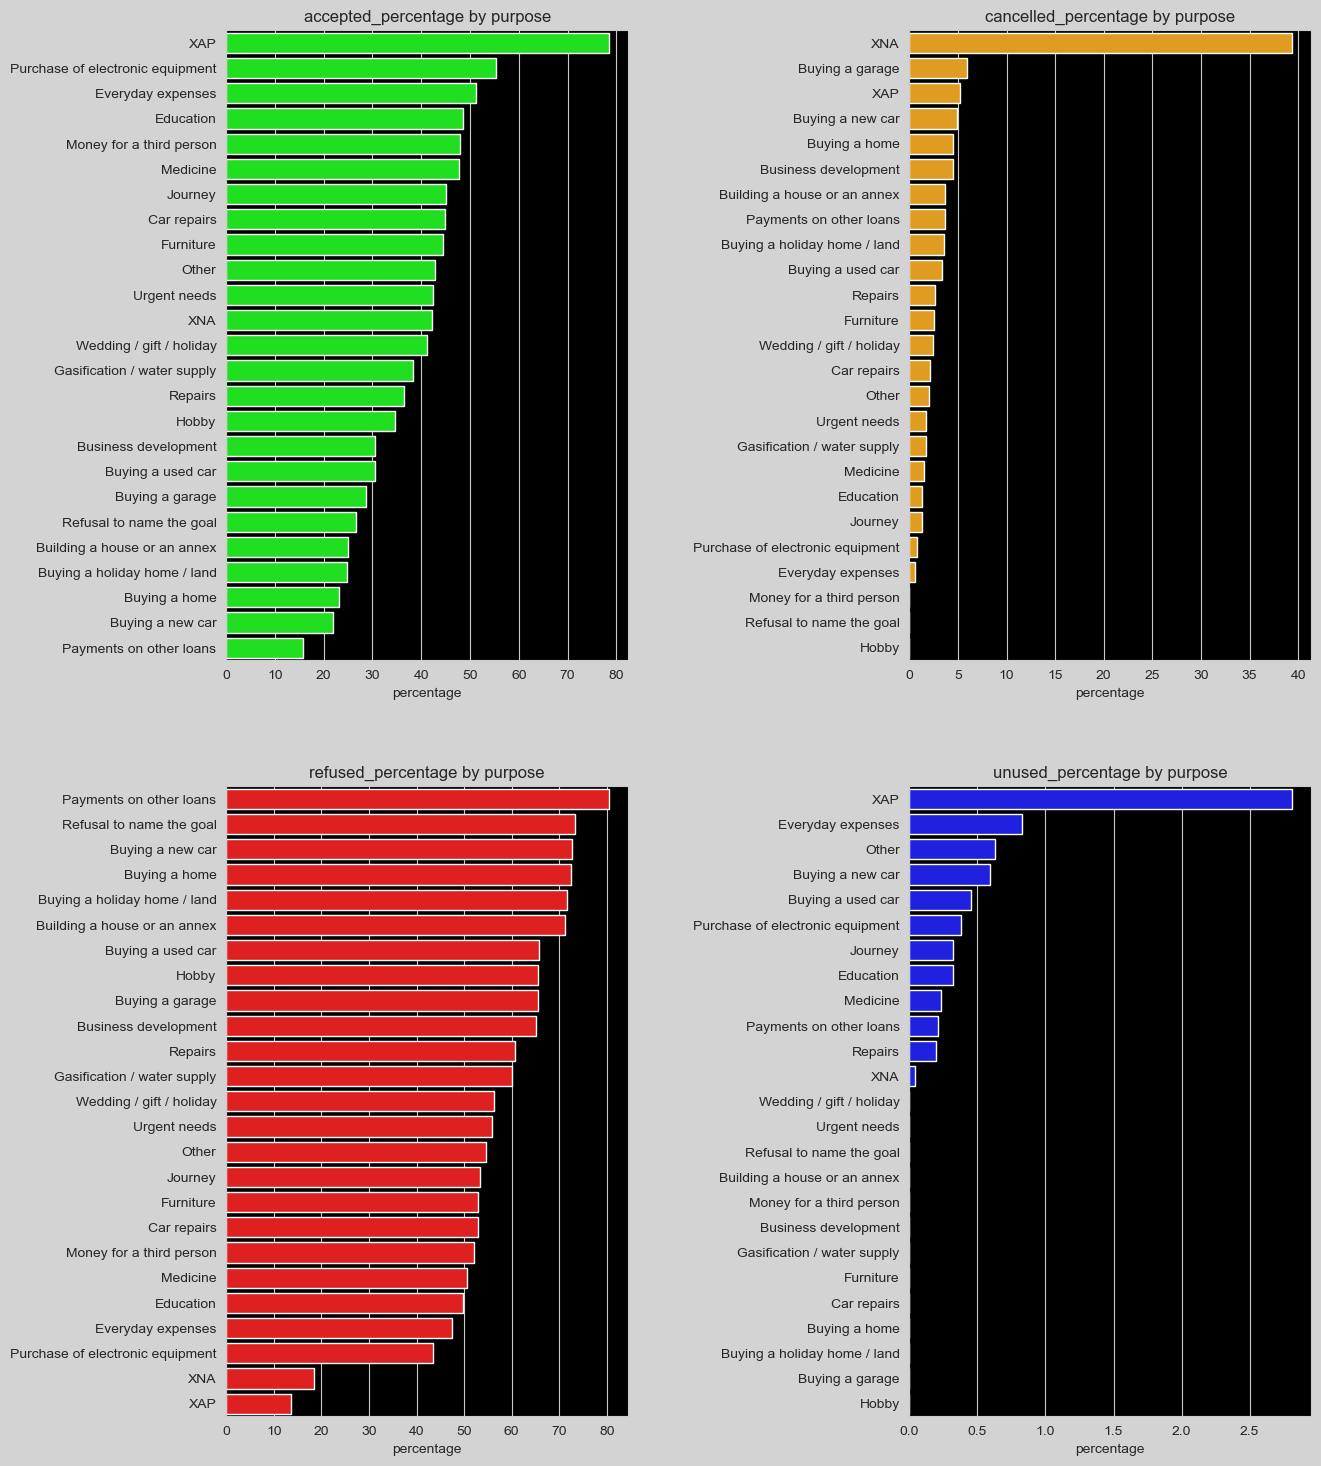

In [181]:
previous_application[["NAME_CASH_LOAN_PURPOSE","NAME_CONTRACT_STATUS"]]
purpose = pd.crosstab(previous_application["NAME_CASH_LOAN_PURPOSE"],previous_application["NAME_CONTRACT_STATUS"])
purpose["a"] = (purpose["Approved"]*100)/(purpose["Approved"]+purpose["Canceled"]+purpose["Refused"]+purpose["Unused offer"])
purpose["c"] = (purpose["Canceled"]*100)/(purpose["Approved"]+purpose["Canceled"]+purpose["Refused"]+purpose["Unused offer"])
purpose["r"] = (purpose["Refused"]*100)/(purpose["Approved"]+purpose["Canceled"]+purpose["Refused"]+purpose["Unused offer"])
purpose["u"] = (purpose["Unused offer"]*100)/(purpose["Approved"]+purpose["Canceled"]+purpose["Refused"]+purpose["Unused offer"])
purpose_new = purpose[["a","c","r","u"]]
purpose_new = purpose_new.stack().reset_index()
purpose_new["NAME_CONTRACT_STATUS"] = purpose_new["NAME_CONTRACT_STATUS"].replace({"a":"accepted_percentage","c":"cancelled_percentage",
                                                               "r":"refused_percentage","u":"unused_percentage"})
lst = purpose_new["NAME_CONTRACT_STATUS"].unique().tolist()
length = len(lst)
cs = ["lime","orange","r","b"]
fig = plt.figure(figsize=(14,18))
fig.set_facecolor("lightgrey")
for i,j,k in itertools.zip_longest(lst,range(length),cs):
    plt.subplot(2,2,j+1)
    dat = purpose_new[purpose_new["NAME_CONTRACT_STATUS"] == i]
    ax = sns.barplot(0,"NAME_CASH_LOAN_PURPOSE",data=dat.sort_values(by=0,ascending=False),color=k)
    plt.ylabel("")
    plt.xlabel("percentage")
    plt.title(i+" by purpose")
    plt.subplots_adjust(wspace = .7)
    ax.set_facecolor("k")
    
#XAP Purpose has been accepted the most
#XNA Purpose loan has been cancelled the most
#Payments on other loans has been refused the most

Client payment methods & reasons for application rejections

NAME_PAYMENT_TYPE - Payment method that client chose to pay for the previous application.

CODE_REJECT_REASON - Why was the previous application rejected.

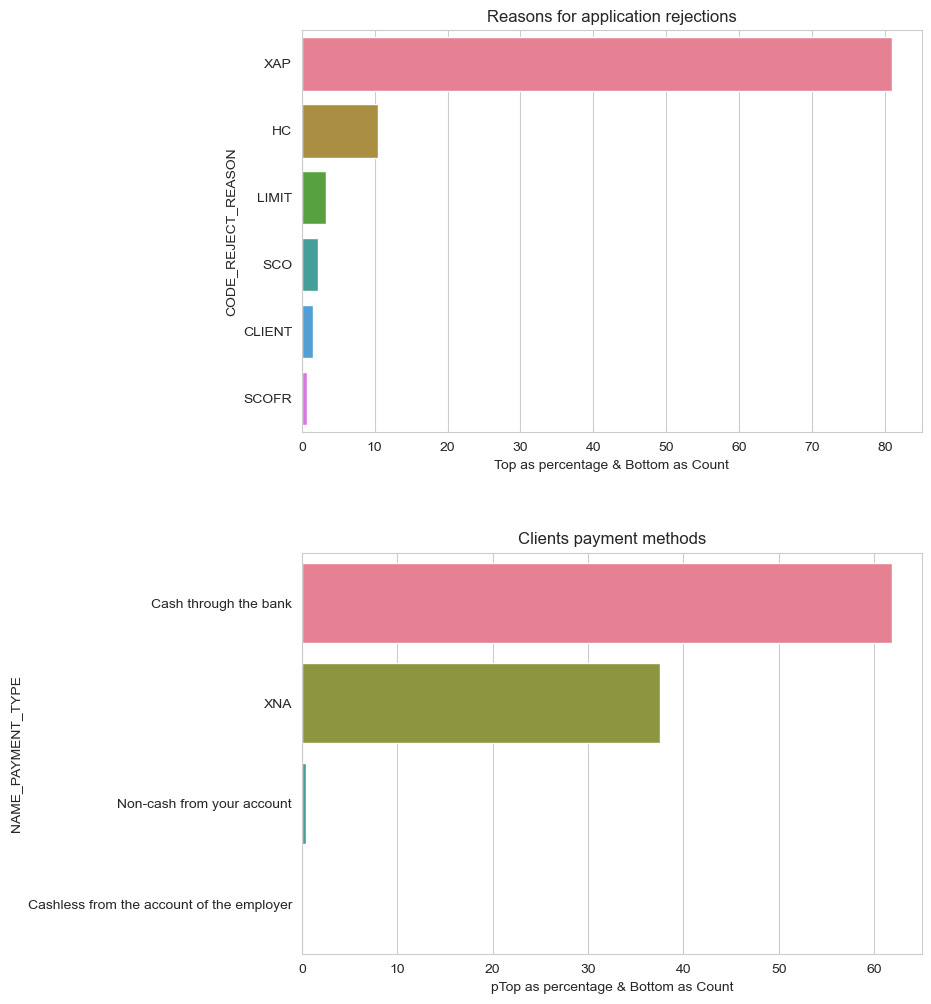

In [189]:
plt.figure(figsize=(8,12))

plt.subplot(211)
rej = previous_application["CODE_REJECT_REASON"].value_counts().reset_index()
rej["Weight_pct"] = round(((rej["CODE_REJECT_REASON"]*100)/rej["CODE_REJECT_REASON"].sum()),2)
ax = sns.barplot("Weight_pct","index",data=rej[:6],palette="husl")
plt.xlabel("Top as percentage & Bottom as Count")
plt.ylabel("CODE_REJECT_REASON")
plt.title("Reasons for application rejections")

#Top  reason for rejection is XAP(81%)

plt.subplot(212)
pay = previous_application["NAME_PAYMENT_TYPE"].value_counts().reset_index()
pay["Weight_pct"] = round(((pay["NAME_PAYMENT_TYPE"]*100)/pay["NAME_PAYMENT_TYPE"].sum()),2)
ax1 = sns.barplot("Weight_pct","index",data=pay,palette="husl")
plt.xlabel("pTop as percentage & Bottom as Count")
plt.ylabel("NAME_PAYMENT_TYPE")
plt.title("Clients payment methods")
plt.subplots_adjust(hspace = .3)

#Top method of payment is cash through bank(62%)


Distribution in Client suite type & client type.

NAME_TYPE_SUITE - Who accompanied client when applying for the previous application.

NAME_CLIENT_TYPE - Was the client old or new client when applying for the previous application.

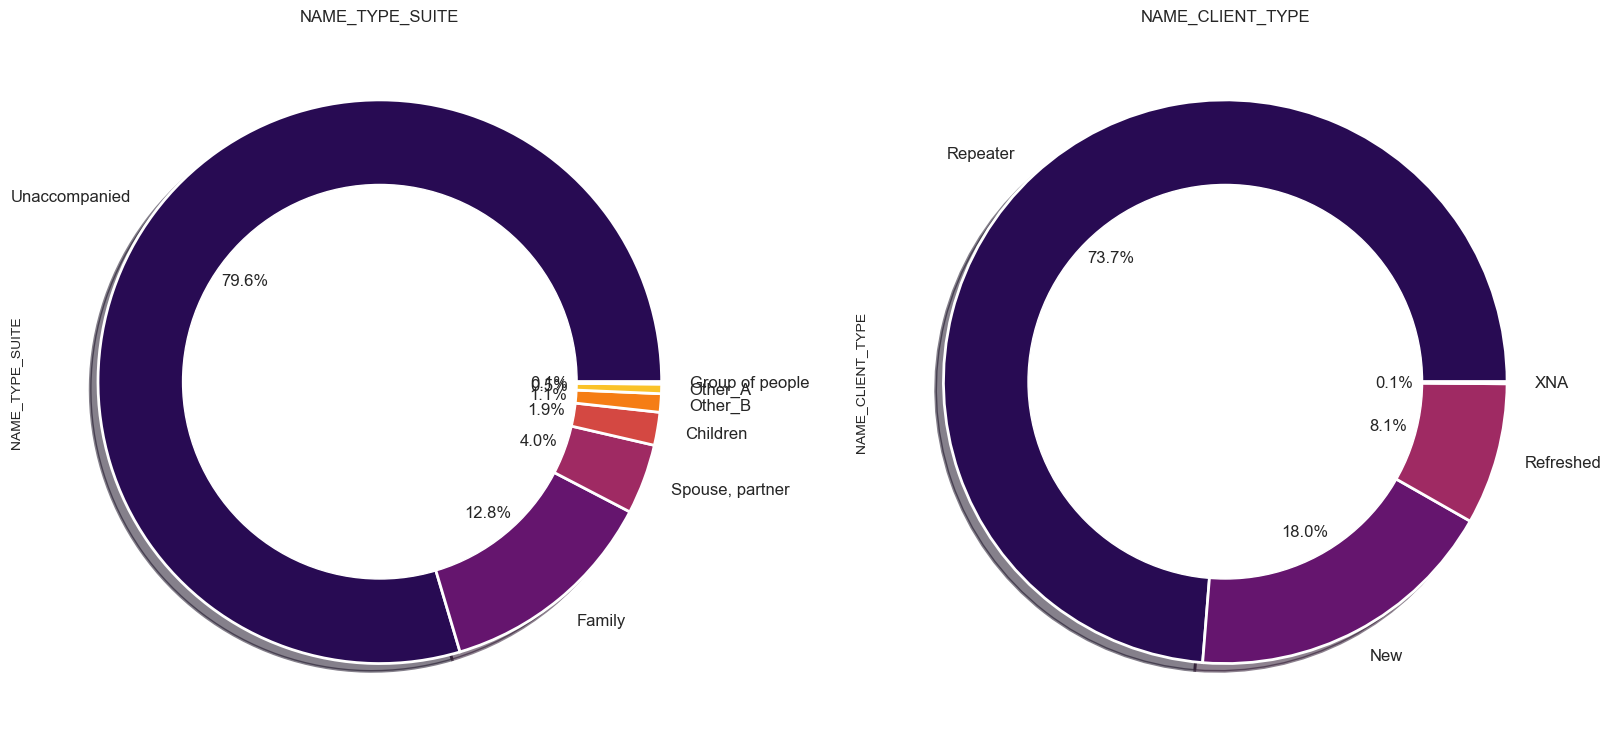

In [190]:
plt.figure(figsize=(20,20))
plt.subplot(121)
previous_application["NAME_TYPE_SUITE"].value_counts().plot.pie(autopct = "%1.1f%%",fontsize=12,
                                                             colors = sns.color_palette("inferno"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)
circ = plt.Circle((0,0),.7,color="white")
plt.gca().add_artist(circ)
plt.title("NAME_TYPE_SUITE")

plt.subplot(122)
previous_application["NAME_CLIENT_TYPE"].value_counts().plot.pie(autopct = "%1.1f%%",fontsize=12,
                                                             colors = sns.color_palette("inferno"),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},shadow =True)
circ = plt.Circle((0,0),.7,color="white")
plt.gca().add_artist(circ)
plt.title("NAME_CLIENT_TYPE")
plt.show()

#Most of the applicants  were unaccompanied when applying for loans
#74% of the clients are repeater

Popular goods for applying loans

NAME_GOODS_CATEGORY - What kind of goods did the client apply for in the previous application.

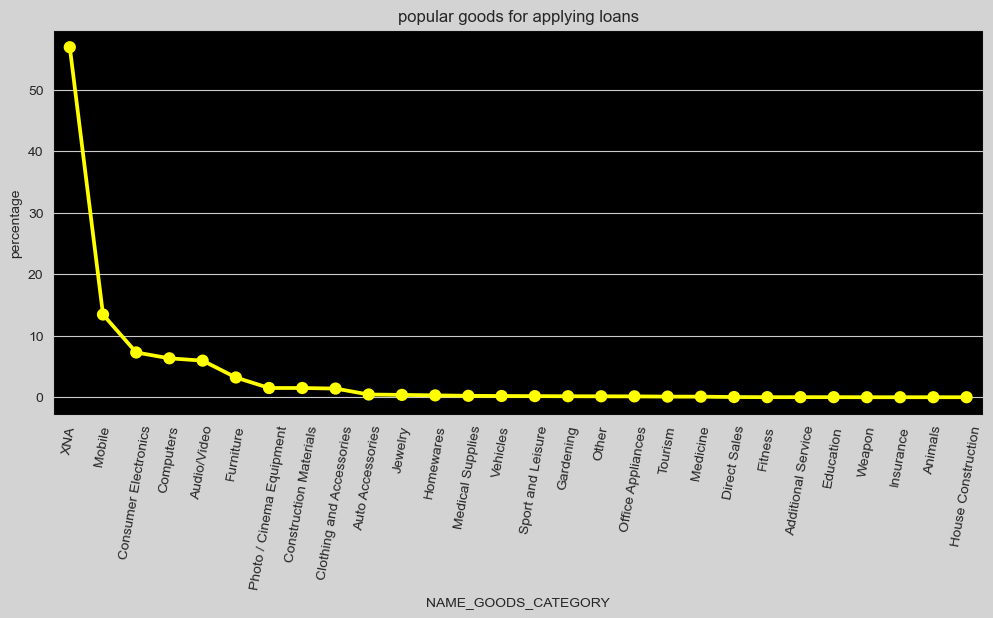

In [191]:
goods = previous_application["NAME_GOODS_CATEGORY"].value_counts().reset_index()
goods["percentage"] = round(goods["NAME_GOODS_CATEGORY"]*100/goods["NAME_GOODS_CATEGORY"].sum(),2)
fig = plt.figure(figsize=(12,5))
ax = sns.pointplot("index","percentage",data=goods,color="yellow")
plt.xticks(rotation = 80)
plt.xlabel("NAME_GOODS_CATEGORY")
plt.ylabel("percentage")
plt.title("popular goods for applying loans")
ax.set_facecolor("k")
fig.set_facecolor('lightgrey')
#XNA,Mobile,Electronics and Computer having the most for applying loans

Previous applications portfolio and product types

NAME_PORTFOLIO - Was the previous application for CASH, POS, CAR, …

NAME_PRODUCT_TYPE - Was the previous application x-sell o walk-in.

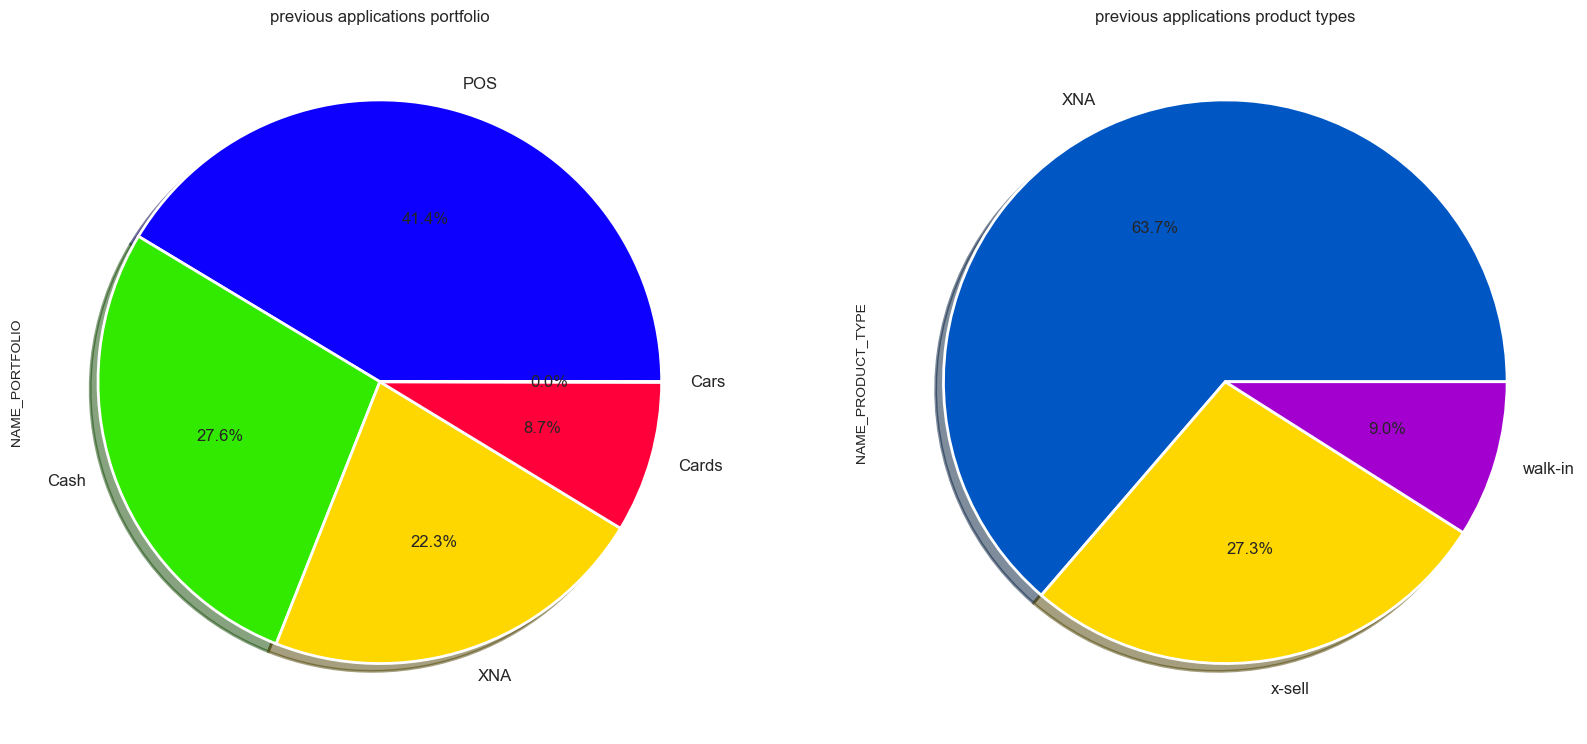

In [193]:
plt.figure(figsize=(20,20))
plt.subplot(121)
previous_application["NAME_PORTFOLIO"].value_counts().plot.pie(autopct = "%1.1f%%",fontsize=12,
                                                             colors = sns.color_palette("prism",5),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},
                                                               shadow =True)
plt.title("previous applications portfolio")
plt.subplot(122)
previous_application["NAME_PRODUCT_TYPE"].value_counts().plot.pie(autopct = "%1.1f%%",fontsize=12,
                                                             colors = sns.color_palette("prism",3),
                                              wedgeprops={"linewidth":2,"edgecolor":"white"},
                                                                  shadow =True)
plt.title("previous applications product types")
plt.show()

#For the portfolio the maximum consists of POS
#For the product types maximum consists of XNA

Approval,canceled and refusal rates by channel types.

CHANNEL_TYPE - Through which channel we acquired the client on the previous application.

NAME_CONTRACT_STATUS- Contract status (approved, cancelled, ...) of previous application.

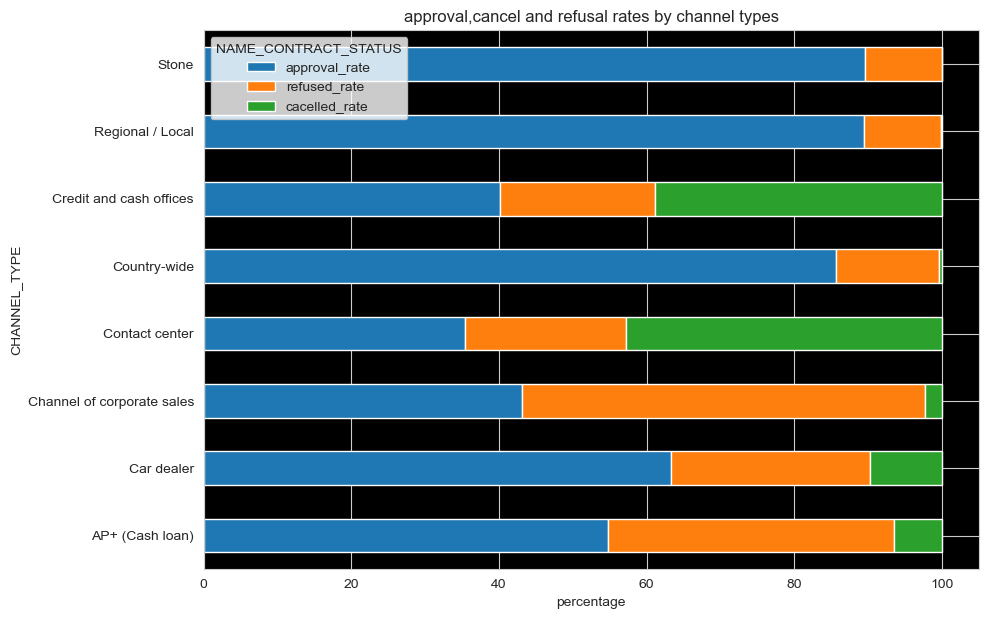

In [198]:
app = pd.crosstab(previous_application["CHANNEL_TYPE"],previous_application["NAME_CONTRACT_STATUS"])
app1 = app
app1["approval_rate"] = app1["Approved"]*100/(app1["Approved"]+app1["Refused"]+app1["Canceled"])
app1["refused_rate"]  = app1["Refused"]*100/(app1["Approved"]+app1["Refused"]+app1["Canceled"])
app1["cacelled_rate"] = app1["Canceled"]*100/(app1["Approved"]+app1["Refused"]+app1["Canceled"])
app2 = app[["approval_rate","refused_rate","cacelled_rate"]]
ax = app2.plot(kind="barh",stacked=True,figsize=(10,7))
ax.set_facecolor("k")
ax.set_xlabel("percentage")
ax.set_title("approval,cancel and refusal rates by channel types")
plt.show()

#Channel like Stone, Regional and Country-Wide have maximum approval rates
#Channel of corporate sale shave maximum refusal rates
#Contact Center and Credit and cash offices have maximum cancellation rate

Highest amount credited seller areas and industries.

NAME_SELLER_INDUSTRY - The industry of the seller.

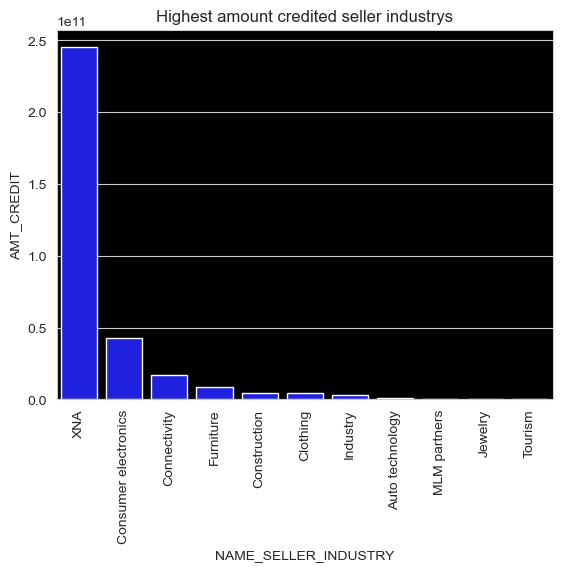

In [199]:
sell = previous_application.groupby("NAME_SELLER_INDUSTRY")["AMT_CREDIT"].sum().reset_index().sort_values(by = "AMT_CREDIT",ascending = False)
ax1=sns.barplot(y = "AMT_CREDIT",x = "NAME_SELLER_INDUSTRY",data=sell,color="b")
ax1.set_facecolor("k")
ax1.set_title("Highest amount credited seller industrys")
plt.xticks(rotation=90)
plt.subplots_adjust(wspace = .5)
fig.set_facecolor("lightgrey")
#XNA is having the major credit amount

Popular terms of previous credit at application.

CNT_PAYMENT - Term of previous credit at application of the previous application.

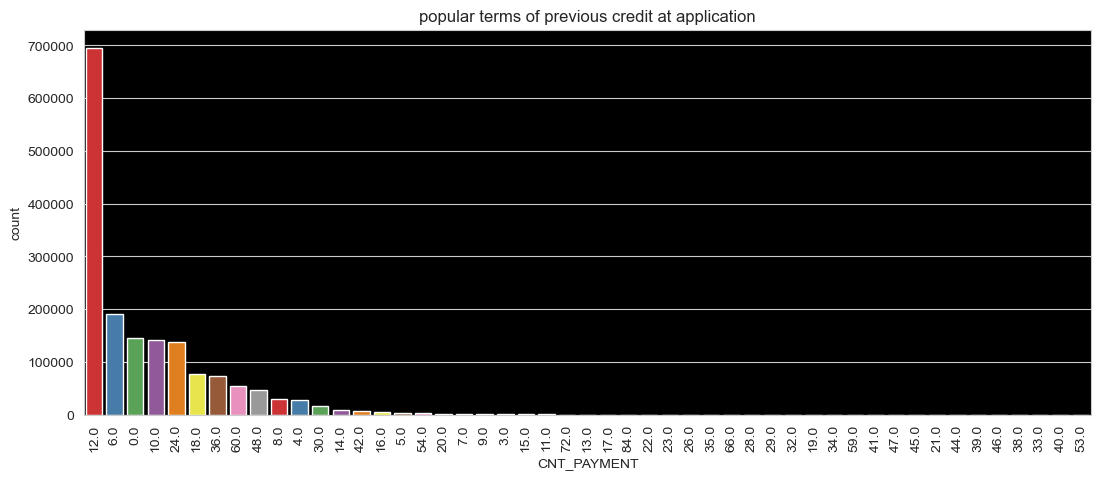

In [200]:
plt.figure(figsize=(13,5))
ax = sns.countplot(previous_application["CNT_PAYMENT"],palette="Set1",order=previous_application["CNT_PAYMENT"].value_counts().index)
ax.set_facecolor("k")
plt.xticks(rotation = 90)
plt.title("popular terms of previous credit at application")
plt.show()

#Popular term of previous credit are 6months ,10months ,1year ,2years & 3 years.

Correlation between variables

Application Data

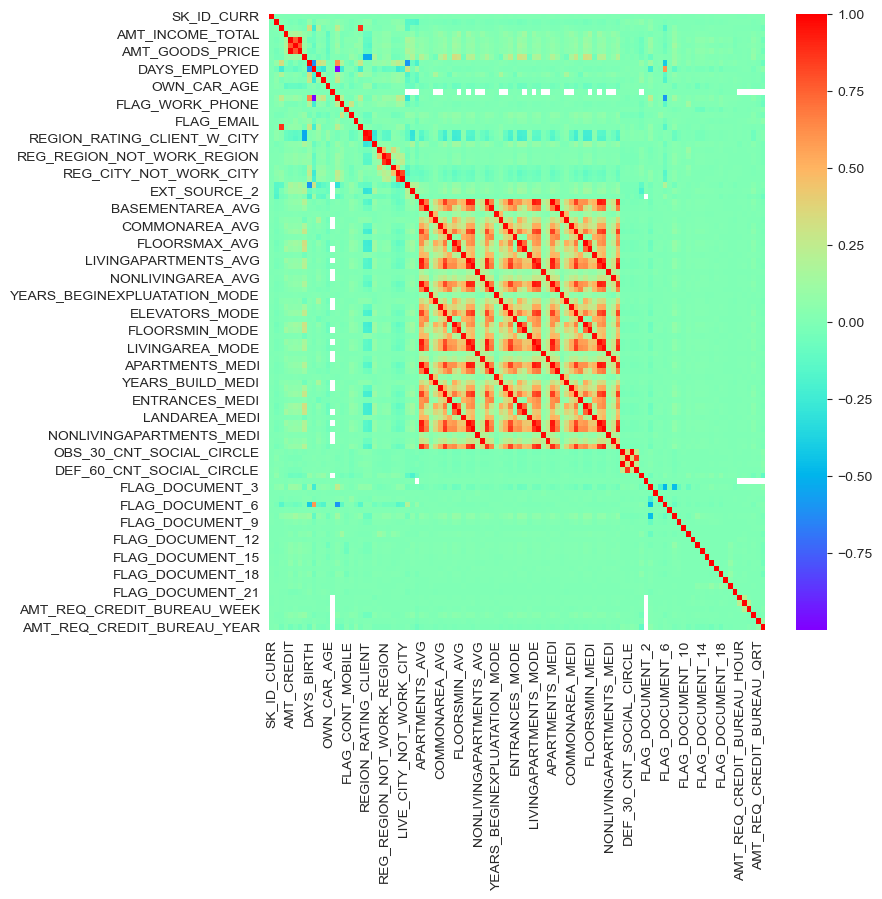

In [201]:
corrmat = application_data.corr() 
  
f, ax = plt.subplots(figsize =(8, 8)) 
sns.heatmap(corrmat, ax = ax, cmap ="rainbow") 
plt.show()

previous_application

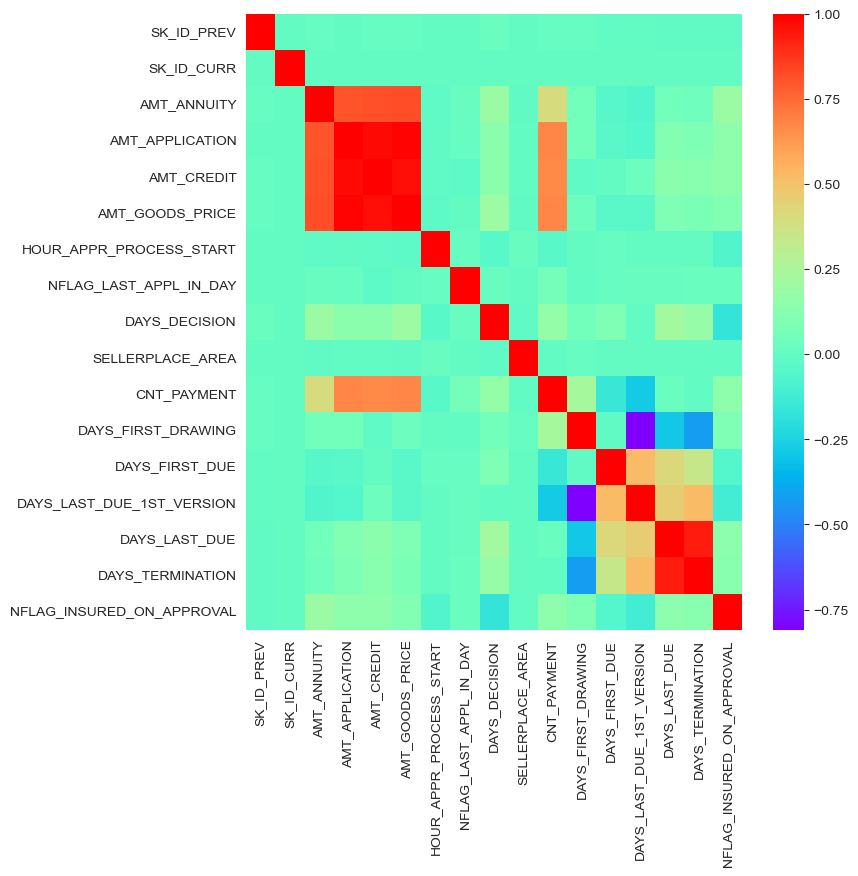

In [202]:
corrmat = previous_application.corr() 
  
f, ax = plt.subplots(figsize =(8, 8)) 
sns.heatmap(corrmat, ax = ax, cmap ="rainbow") 
plt.show()

In [213]:
#To Correlated values for previous applications
corrmat = previous_application.corr() 
corrdf = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(np.bool))
corrdf = corrdf.unstack().reset_index()
corrdf.columns = ['Var1', 'Var2', 'Correlation']
corrdf.dropna(subset = ['Correlation'], inplace = True)
corrdf['Correlation'] = round(corrdf['Correlation'], 2)
corrdf['Correlation'] = abs(corrdf['Correlation'])
corrdf.sort_values(by = 'Correlation', ascending = False).head(10)

,Var1,Var2,Correlation
88,AMT_GOODS_PRICE,AMT_APPLICATION,0.99
71,AMT_CREDIT,AMT_APPLICATION,0.98
89,AMT_GOODS_PRICE,AMT_CREDIT,0.97
269,DAYS_TERMINATION,DAYS_LAST_DUE,0.94
87,AMT_GOODS_PRICE,AMT_ANNUITY,0.82
53,AMT_APPLICATION,AMT_ANNUITY,0.81
70,AMT_CREDIT,AMT_ANNUITY,0.81
232,DAYS_LAST_DUE_1ST_VERSION,DAYS_FIRST_DRAWING,0.81
173,CNT_PAYMENT,AMT_APPLICATION,0.68
175,CNT_PAYMENT,AMT_GOODS_PRICE,0.68


Application Data

Top 10 Correlation Fields for Repayer

In [215]:
df_repayer = upd_applicationn_data[upd_applicationn_data['TARGET'] == 0]
df_defaulter = upd_applicationn_data[upd_applicationn_data['TARGET'] == 1]

In [216]:
#Top 10 Correlated fileds of repayer
corrmat = df_repayer.corr() 
corrdf = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(np.bool))
corrdf = corrdf.unstack().reset_index()
corrdf.columns = ['Var1', 'Var2', 'Correlation']
corrdf.dropna(subset = ['Correlation'], inplace = True)
corrdf['Correlation'] = round(corrdf['Correlation'], 2)
corrdf['Correlation'] = abs(corrdf['Correlation'])
corrdf.sort_values(by = 'Correlation', ascending = False).head(10)

,Var1,Var2,Correlation
893,FLAG_EMP_PHONE,DAYS_EMPLOYED,1.00
2411,FLOORSMAX_MEDI,FLOORSMAX_AVG,1.00
2689,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,1.00
412,AMT_GOODS_PRICE,AMT_CREDIT,0.99
2275,FLOORSMAX_MODE,FLOORSMAX_AVG,0.99
2413,FLOORSMAX_MEDI,FLOORSMAX_MODE,0.99
2342,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,0.99
2206,YEARS_BEGINEXPLUATATION_MODE,YEARS_BEGINEXPLUATATION_AVG,0.97
2344,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,0.96
1379,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.95


In [217]:
#Top 10 Correlated fileds of defaulter
corrmat = df_defaulter.corr() 
corrdf = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(np.bool))
corrdf = corrdf.unstack().reset_index()
corrdf.columns = ['Var1', 'Var2', 'Correlation']
corrdf.dropna(subset = ['Correlation'], inplace = True)
corrdf['Correlation'] = round(corrdf['Correlation'], 2)
corrdf['Correlation'] = abs(corrdf['Correlation'])
corrdf.sort_values(by = 'Correlation', ascending = False).head(10)

,Var1,Var2,Correlation
2342,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,1.00
2411,FLOORSMAX_MEDI,FLOORSMAX_AVG,1.00
893,FLAG_EMP_PHONE,DAYS_EMPLOYED,1.00
2689,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,1.00
2275,FLOORSMAX_MODE,FLOORSMAX_AVG,0.99
2413,FLOORSMAX_MEDI,FLOORSMAX_MODE,0.99
2344,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,0.98
2206,YEARS_BEGINEXPLUATATION_MODE,YEARS_BEGINEXPLUATATION_AVG,0.98
412,AMT_GOODS_PRICE,AMT_CREDIT,0.98
1379,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.96


In [218]:
mergeddf =  pd.merge(application_data,previous_application,on='SK_ID_CURR')
mergeddf.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,Auto technology,24.0,low_normal,POS other with interest,365243.0,-565.0,125.0,-25.0,-17.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-716.0,-386.0,-536.0,-527.0,1.0
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Furniture,6.0,middle,POS industry with interest,365243.0,-797.0,-647.0,-647.0,-639.0,0.0
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Consumer electronics,12.0,middle,POS household with interest,365243.0,-2310.0,-1980.0,-1980.0,-1976.0,1.0
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,Connectivity,4.0,middle,POS mobile without interest,365243.0,-784.0,-694.0,-724.0,-714.0,0.0


In [228]:
y = mergeddf.groupby('SK_ID_CURR').size()
dfA = mergeddf.groupby('SK_ID_CURR').agg({'TARGET': np.sum})
dfA['count'] = y
display(dfA.head(10))

,TARGET,count
SK_ID_CURR,,
100002,1,1
100003,0,3
100004,0,1
100006,0,9
100007,0,6
100008,0,5
100009,0,7
100010,0,1
100011,0,4


In [229]:
dfA.sort_values(by = 'count',ascending=False).head(10)

,TARGET,count
SK_ID_CURR,,
265681,0,73
173680,0,72
242412,0,68
206783,0,67
389950,0,64
382179,0,64
198355,0,63
345161,0,62
446486,0,62


In [230]:
df_repayer = dfA[dfA['TARGET'] == 0]
df_defaulter = dfA[dfA['TARGET'] == 1]

Repayers' Borrowing History

In [231]:
df_repayer.sort_values(by = 'count',ascending=False).head(10)

,TARGET,count
SK_ID_CURR,,
265681,0,73
173680,0,72
242412,0,68
206783,0,67
382179,0,64
389950,0,64
198355,0,63
446486,0,62
345161,0,62


Defaulters' Borrowing History

In [232]:
df_defaulter.sort_values(by = 'count',ascending=False).head(10)

,TARGET,count
SK_ID_CURR,,
100002,1,1
333349,1,1
333587,1,1
333582,1,1
333534,1,1
333506,1,1
333419,1,1
333355,1,1
333337,1,1
